# Experiment 1: data parsing and analyses

In [1]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import os
import pickle
import glob 
import itertools
from statannotations.Annotator import Annotator
import json
from scipy.stats import ttest_rel, wilcoxon
from collections import Counter
import ast
from collections import deque
import matplotlib.cm as cm
from matplotlib import gridspec
import matplotlib.patches as patches
import math
from copy import deepcopy
import pickle
import heapq
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
from patsy import dmatrix, build_design_matrices  # <- key import
from scipy.spatial.distance import cdist, jensenshannon
from scipy.optimize import linprog

import models.mdps as mdps
import models.jit as jit





figpath = os.path.join("fig")
fitspath = os.path.join("modelfits")
data_savepath = os.path.join("data")
datapath = os.path.join("..","experiment","data", "exp1")

start_goal_pos = [(8,1),(8,15)]
maze_size = 17

In [2]:
def maze_to_char_array(maze):
    return np.array([list(row) for row in maze])

def grid_to_rowstrings(s: str):
    grid = json.loads(s)          # -> list[list[str]]
    return [''.join(row) for row in grid]


def solve_maze_BestFirstSearch(maze, start=None, end=None, heuristic="Manhattan"):
    """
    Perform greedy best-first search on a rectangular maze.

    Parameters
    ----------
    maze : List[str]
        Maze represented as a list of strings of equal length.
        maze[row][col] == '#' for walls, '.' for free space.
    start : (col, row)
        Tuple giving the starting cell coordinates.
    end : (col, row)
        Tuple giving the end cell coordinates.
    heuristic: "Manhattan" or "Euclidean"
        Heuristic value function used to guide which square to evaluate next. 

    Returns
    -------
    path : List[(col, row)]
        The sequence of cells from start to end (inclusive), or [] if none found.
    evaluated : List[(col, row)]
        The cells popped from the priority queue, in order of expansion.
    walls : List[(col, row)]
        All wall‐cells that were examined as neighbors during the search.
    """
    width  = len(maze[0])
    height = len(maze)
    
    if(start is None):
        for x in range(width):
            if maze[0][x] == '.':
                start = (x, 0)
                break
        for x in range(width):
            if maze[height-1][x] == '.':
                end = (x, height-1)
                break

    def h(cell, distance="Manhattan"):
        c, r = cell
        gc, gr = end
        if(distance=="Manhattan"):
            return abs(c - gc) + abs(r - gr)
        elif(distance=="Euclidean"):
            return np.sqrt((c - gc)**2 + (r - gr)**2)

    # Min-heap of (priority, (col, row))
    frontier = [(h(start, distance=heuristic), start)]
    came_from = {start: None}
    visited   = {start}
    evaluated  = []
    walls      = []

    while frontier:
        _, current = heapq.heappop(frontier)
        evaluated.append(current)

        if current == end:
            break

        c, r = current
        for dc, dr in [(0,-1), (0,1), (-1,0), (1,0)]:
            nc, nr = c + dc, r + dr
            if not (0 <= nc < width and 0 <= nr < height):
                continue

            neighbor = (nc, nr)
            if neighbor in visited:
                continue

            if maze[nr][nc] == '#':
                walls.append(neighbor)
                continue

            visited.add(neighbor)
            came_from[neighbor] = current
            heapq.heappush(frontier, (h(neighbor, distance=heuristic), neighbor))

    # Reconstruct path
    path = []
    if end in came_from:
        node = end
        while node is not None:
            path.append(node)
            node = came_from[node]
        path.reverse()

    return path, evaluated, walls   
    

def visualize_maze_colored(maze,
                           num_colors,
                           figsize=None,
                           start_goal_pos = None,
                           start_goal=False,
                           path=None,
                           legend=False,
                           palette_name='tab20',
                           adj_sq_notsamecolor = True,
                           plt_show=True):
    """
    Visualize a maze with randomly assigned colors; but ensure no two
    adjacent cells of the same type share a color (greedy coloring).
    Parameters:
      - maze: list of strings ('#' walls, other symbols are all passages)
      - num_colors: total number of colors (must be >=2 and even)
      - figsize: tuple for figure size
      - start_goal: if True mark only start/end, else draw full path
      - path: list of (x,y) coordinates to overlay
      - legend: whether to draw the maze+legend (True) or just the maze (False)
      - palette_name: Matplotlib colormap name, e.g. 'tab20' or 'gray'
      - adj_sq_notsamecolor: if True, ensure no two adjacent cells of the same type share a color.
      - plt_show: if True, calls plt.show(); else leaves the figure open for saving downstream
    """
    # Randomize colors for each trial
    cmap = plt.get_cmap(palette_name)
    
    if(palette_name != "gray"):
        colors = [cmap(i) for i in range(20)]
        random.shuffle(colors)
        # 2. Split into wall-colors and passage-colors
        half = num_colors // 2
        wall_colors = colors[:half]
        passage_colors = colors[half:num_colors]
    else: # Black and white maze
#         positions = np.linspace(0, 1, num_colors)
        positions = np.linspace(0.85,1, num_colors)
        colors = [cmap(pos) for pos in positions]
        # 2. Split into wall-colors and passage-colors
        half = num_colors // 2
        wall_colors = colors[0:half]
        passage_colors = colors[-half:]

    H, W = len(maze), len(maze[0])
    # 2) Greedy coloring: no same‐type neighbors share a color
    img = np.zeros((H, W, 3), dtype=float)
    
    if(adj_sq_notsamecolor): # Ensure that no adjacent squares share the same color. Works only with num_colors>=8, due to the four-color theorem.
        assigned = [[None]*W for _ in range(H)]
        for y in range(H):
            for x in range(W):
                palette = wall_colors if maze[y][x] == '#' else passage_colors
                # collect forbidden from up and left if same type
                forbidden = set()
                for dy, dx in [(-1,0),(0,-1)]:
                    ny, nx = y+dy, x+dx
                    if 0 <= ny < H and 0 <= nx < W and maze[ny][nx] == maze[y][x]:
                        c = assigned[ny][nx]
                        if c is not None:
                            forbidden.add(c)
                # choose from palette avoiding forbidden
                choices = [c for c in palette if c not in forbidden]
                chosen = random.choice(choices) if choices else random.choice(palette)
                assigned[y][x] = chosen
                img[y, x] = chosen[:3]
    else:
        for y in range(H):
            for x in range(W):
                if maze[y][x] == '#':
                    color = random.choice(wall_colors)
                else:
                    color = random.choice(passage_colors)
                img[y, x] = color[:3]  # drop alpha channel

    # 3) Display
    if not legend:
        if figsize is None:
            plt.figure(figsize=(W/5, H/5))
        else:
            plt.figure(figsize=figsize)
        plt.imshow(img, interpolation='nearest')
        plt.xticks([]); plt.yticks([])
        if path:
            xs, ys = zip(*path)
            if(start_goal_pos is None):
                ax_maze.plot(xs[0], ys[0], '.', color='red', markersize=20)
                ax_maze.plot(xs[-1], ys[-1], '*', color='red', markersize=12)
            else:
                ax_maze.plot(start_goal_pos[0][0], start_goal_pos[0][1], '.', color='red', markersize=20)
                ax_maze.plot(start_goal_pos[1][0], start_goal_pos[1][1], '*', color='red', markersize=12)
            if not start_goal:
                plt.plot(xs, ys, color='red', linewidth=2)
        if plt_show:
            plt.show()
    else:
        # maze+legend side by side
        if figsize is None:
            figsize = ((W + half)/5, H/5)
        fig, (ax_maze, ax_leg) = plt.subplots(
            1, 2,
            figsize=figsize,
            gridspec_kw={'width_ratios': [W, max(8, num_colors)//2 * 1.2],
                         'wspace': 0.25}
        )
        # draw maze
        ax_maze.imshow(img, interpolation='nearest')
        ax_maze.set_xticks([]); ax_maze.set_yticks([])
        ax_maze.set_aspect('equal')
        if path:
            xs, ys = zip(*path)
            if(start_goal_pos is None):
                ax_maze.plot(xs[0], ys[0], '.', color='red', markersize=20)
                ax_maze.plot(xs[-1], ys[-1], '*', color='red', markersize=12)
            else:
                ax_maze.plot(start_goal_pos[0][0], start_goal_pos[0][1], '.', color='red', markersize=20)
                ax_maze.plot(start_goal_pos[1][0], start_goal_pos[1][1], '*', color='red', markersize=12)
            if not start_goal: # Visualize only start and end points of the maze, not path
                ax_maze.plot(xs, ys, color='red', linewidth=2)

        # draw legend
        legend_size = 1.5
        ax_leg.axis('off')
        ax_leg.set_aspect('equal')
        ax_leg.set_xlim(-1, (max(8, num_colors)//2 + 0.2)*legend_size)
        ax_leg.set_ylim(-2*legend_size, 3*legend_size)

        row_gap = 0.75
        # walls row
        for i, col in enumerate(wall_colors):
            ax_leg.add_patch(patches.Rectangle(
                (i*legend_size, legend_size + row_gap),
                legend_size, legend_size,
                facecolor=col[:3], edgecolor='k'
            ))
        ax_leg.text(-0.5, legend_size*1.5+row_gap, 'Danger:',
                    va='center', ha='right', fontsize=10)
        # spaces row
        for i, col in enumerate(passage_colors):
            ax_leg.add_patch(patches.Rectangle(
                (i*legend_size, 0),
                legend_size, legend_size,
                facecolor=col[:3], edgecolor='k'
            ))
        ax_leg.text(-0.5, legend_size*0.5, 'Safety:',
                    va='center', ha='right', fontsize=10)

        if plt_show:
            plt.show()
        else:
            fig.tight_layout()

    return {"ax_maze":ax_maze, "wall_colors": wall_colors,
            "passage_colors": passage_colors}

def path_on_rim(path, start_goal_pos = [(8,1),(8,15)], maze_size = 17):
    '''Given a path, check if it has never traversed the central maze.
        paths: 1D list. Each of its elements is one position along the path.
        start_goal_pos: starting and end point. Traversing these points does not mean the path is not on the rim.
        maze_size: used to determine where the rim positions are.'''
    paths_use_rim = []
    max_i = maze_size - 1
    if(path==[start_goal_pos[0]]): # If subject did not move at all, don't count this as using rim path
        return False

    for x, y in path:
        if (x, y) in set(start_goal_pos):
            continue
        # must be inside grid
        if not (0 <= x <= max_i and 0 <= y <= max_i):
            return False
        # on rim iff touches any outer edge
        if not (x in (0, max_i) or y in (0, max_i)):
            return False
    return True
        
    
def keypresses_to_position(key_presses, start_goal_pos=[(8,1),(8,15)], maze_size = 17):
    '''Given a set of key presses ['w','a','b',...], convert it to the corresponding trajectory of positions'''
    trajectory = [np.array(list(start_goal_pos[0]))] # start at start point
    
    for key_idx in range(len(key_presses)): #key_presses[0] moves from start point to first step. 
        prev_position = trajectory[key_idx]
        key = key_presses[key_idx]
        
        if(key=="b"): # Backtrack
            trajectory.append(trajectory[max(0,key_idx-1)])
            continue
        elif(key=="r"): # Return to start point
            trajectory.append(np.array(list(start_goal_pos[0]))) # Return to start
            continue
        else:
            if(key=="w"):
                move = np.array([0,-1])
            elif(key=="a"):
                move = np.array([-1,0])
            elif(key=="s"):
                move = np.array([0,1])
            elif(key=="d"):
                move = np.array([1,0])
            pseudo_pos = prev_position+move 
            pseudo_pos[0] = min(max(pseudo_pos[0],0), maze_size-1)
            pseudo_pos[1] = min(max(pseudo_pos[1],0), maze_size-1)
            trajectory.append(pseudo_pos)
        
    trajectory = [(int(pos[0]), int(pos[1])) for pos in trajectory]
    return trajectory
            
def find_last_occurrence_of_tuple(list_of_tuples, target_tuple):
    """
    Finds the index of the last occurrence of a target tuple in a list of tuples.

    Args:
        list_of_tuples: The list of tuples to search within.
        target_tuple: The tuple to find.

    Returns:
        The index of the last occurrence of the target tuple, or None if not found.
    """
    for r_idx, current_tuple in enumerate(reversed(list_of_tuples)):
        if current_tuple == target_tuple:
            return len(list_of_tuples) - 1 - r_idx
    return None        
 
    
def solve_maze_BestFirstSearch(maze, start=None, end=None, heuristic="Manhattan"):
    """
    Perform greedy best-first search on a rectangular maze.

    Parameters
    ----------
    maze : List[str]
        Maze represented as a list of strings of equal length.
        maze[row][col] == '#' for walls, '.' for free space.
    start : (col, row)
        Tuple giving the starting cell coordinates.
    end : (col, row)
        Tuple giving the end cell coordinates.
    heuristic: "Manhattan" or "Euclidean"
        Heuristic value function used to guide which square to evaluate next. 

    Returns
    -------
    path : List[(col, row)]
        The sequence of cells from start to end (inclusive), or [] if none found.
    evaluated : List[(col, row)]
        The cells popped from the priority queue, in order of expansion.
    walls : List[(col, row)]
        All wall‐cells that were examined as neighbors during the search.
    """
    width  = len(maze[0])
    height = len(maze)
    
    if(start is None):
        for x in range(width):
            if maze[0][x] == '.':
                start = (x, 0)
                break
        for x in range(width):
            if maze[height-1][x] == '.':
                end = (x, height-1)
                break

    def h(cell, distance="Manhattan"):
        c, r = cell
        gc, gr = end
        if(distance=="Manhattan"):
            return abs(c - gc) + abs(r - gr)
        elif(distance=="Euclidean"):
            return np.sqrt((c - gc)**2 + (r - gr)**2)

    # Min-heap of (priority, (col, row))
    frontier = [(h(start, distance=heuristic), start)]
    came_from = {start: None}
    visited   = {start}
    evaluated  = []
    walls      = []

    while frontier:
        _, current = heapq.heappop(frontier)
        evaluated.append(current)

        if current == end:
            break

        c, r = current
        for dc, dr in [(0,-1), (0,1), (-1,0), (1,0)]:
            nc, nr = c + dc, r + dr
            if not (0 <= nc < width and 0 <= nr < height):
                continue

            neighbor = (nc, nr)
            if neighbor in visited:
                continue

            if maze[nr][nc] == '#':
                walls.append(neighbor)
                continue

            visited.add(neighbor)
            came_from[neighbor] = current
            heapq.heappush(frontier, (h(neighbor, distance=heuristic), neighbor))

    # Reconstruct path
    path = []
    if end in came_from:
        node = end
        while node is not None:
            path.append(node)
            node = came_from[node]
        path.reverse()

    return path, evaluated, walls
   

# if __name__ == '__main__':
#     w = int(input("Enter maze width (cells): "))
#     h = int(input("Enter maze height (cells): "))
#     m = generate_maze(w, h)
#     p = solve_maze(m)
#     visualize_maze(m, p)


def make_vc_formula(group_col, random_slope_terms):
    '''This computes the random effects formula for BinomialBayesMixedGLM.
        Importantly, for categorical predictors, the random effects are separately specified for each value.'''
    vc = {f"ri_{group_col}": f"0 + C({group_col})"}  # random intercepts
    for term in random_slope_terms:
        key = f"rs_{group_col}_{term}".replace("(", "").replace(")", "").replace(" ", "")
        vc[key] = f"0 + C({group_col}):{term}"
    return vc

def logloss_brier_acc(y_true, p_pred, eps=1e-12):
    '''Given y_true (ground-truth labels) and p_pred from the fitted model, compute losses:
        nll: summed cross-entropy loss, divided by the number of trials.
        brier: MSE between y_true and p_pred.
        accuracy: using the 0.5 threshold over p_pred values, return binary prediction accuracy.
    '''
    p = np.clip(np.asarray(p_pred), eps, 1 - eps)
    y = np.asarray(y_true)
    nll = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
    return float(nll) / len(y), float(np.mean((p - y) ** 2)), float(np.mean((p >= 0.5).astype(int) == y))

def cv_glmm_kfold(df, response, group, fixed_formula, random_slopes, n_folds=5, random_state=0):
    '''Fit logistic GLME.
        df: dataset.
        response: y (binary)
        group: random effects are grouped by this variable (Subj)
        fixed_formula: fixed effects
        random_slopes: random effects; for categorical variables, separate random effects for each value they make take on.'''
    # sanity check
    uniq = set(np.unique(df[response]))
    if not uniq.issubset({0, 1}):
        raise ValueError(f"{response} must be 0/1, got {uniq}")

    formula = f"{response} ~ {fixed_formula}"
    vc = make_vc_formula(group, random_slopes)
    print(formula)
    print(vc)
    model_full = BinomialBayesMixedGLM.from_formula(formula, vc, df)
    res_full = model_full.fit_vb()

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    rows = []
    for k, (tr_idx, te_idx) in enumerate(kf.split(df), start=1):
        train = df.iloc[tr_idx].copy()
        test  = df.iloc[te_idx].copy()

        # Fit model (Variational Bayes)
        model = BinomialBayesMixedGLM.from_formula(formula, vc, train)
        res = model.fit_vb()

        # ---- Build test fixed-effects design using training DesignInfo
        # res.model.data.design_info is the Patsy design for *fixed effects*
        design_info_fe = res.model.data.design_info   # fixed-effects DesignInfo
        # Construct test FE matrix consistent with the training coding/levels
        X_test = build_design_matrices([design_info_fe], test, return_type='dataframe')[0]

        # Extract fixed-effect coefficients (first q params)
        q = X_test.shape[1]
        beta = np.asarray(res.params[:q])

        # Predict probabilities via logistic link
        lin = X_test.values @ beta
        p_test = 1.0 / (1.0 + np.exp(-lin))

        # Losses
        mll, brier, acc = logloss_brier_acc(test[response].values, p_test)

        rows.append(dict(fold=k, n_train=len(train), n_test=len(test),
                         mean_logloss=mll, brier=brier, acc=acc))

    out = pd.DataFrame(rows)
    avg = out[["mean_logloss", "brier", "acc"]].mean()
    return out, avg.to_dict(), model_full, res_full


def cv_lmm_kfold(
    df, response, group, fixed_formula, random_formula,
    n_folds=5, random_state=0, include_re_on_test=True
):
    """
    K-fold CV for Linear Mixed Model (LMM).

    Parameters
    ----------
    df : DataFrame
    response : str              # e.g., "y"
    group : str                 # e.g., "Subj"
    fixed_formula : str         # e.g., "y ~ x1 + C(cond) + trial"
    random_formula : str        # e.g., "~ 1 + trial" or "~ 1"
    n_folds : int
    random_state : int
    include_re_on_test : bool   # if True, add Z*b_g for groups seen in training; unseen groups get RE=0

    Returns
    -------
    fold_table : DataFrame with per-fold MSE
    avg_mse : float
    model_full, res_full : fitted full-data model & results (REML=False)
    """
    # Fit once on full data for reference
    model_full = smf.mixedlm(fixed_formula, data=df, groups=df[group], re_formula=random_formula)
    res_full = model_full.fit(reml=False)

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    rows = []

    for k, (tr_idx, te_idx) in enumerate(kf.split(df), start=1):
        train = df.iloc[tr_idx].copy()
        test  = df.iloc[te_idx].copy()

        # Fit on training fold
        model = smf.mixedlm(fixed_formula, data=train, groups=train[group], re_formula=random_formula)
        res = model.fit(reml=False)

        # ----- Fixed-effects test design (Patsy) using training design info
        fe_design_info = res.model.data.design_info
        X_test = build_design_matrices([fe_design_info], test, return_type='dataframe')[0]
        fe_beta = res.fe_params.to_numpy()
        y_pred = X_test.to_numpy() @ fe_beta  # population prediction

        if include_re_on_test:
            # ----- Random-effects design info from training, then build Z_test
            # Build training Z to capture its design_info (must mirror random_formula)
            Z_train = dmatrix(random_formula, train, return_type='dataframe')
            re_design_info = Z_train.design_info
            Z_test = build_design_matrices([re_design_info], test, return_type='dataframe')[0].to_numpy()

            # res.random_effects: dict mapping group label -> vector (length == n_random_effects)
            # Add Z*b_g for test rows whose group was seen in training
            re_by_group = res.random_effects  # {group_value: Series}
            test_groups = test[group].to_numpy()

            # Build an array of per-row RE contributions (default zeros)
            re_add = np.zeros(len(test_groups), dtype=float)

            # Pre-extract group->b_g vector (ndarray) once
            cache_bg = {g: np.asarray(b) for g, b in re_by_group.items()}

            # Efficient vectorized add: for each seen group in the test set, add Z_g @ b_g
            for g in np.unique(test_groups):
                if g in cache_bg:
                    idx = np.where(test_groups == g)[0]
                    b_g = cache_bg[g]
                    re_add[idx] = (Z_test[idx] @ b_g)

            y_pred = y_pred + re_add  # add random effects for seen groups

        # MSE on test fold
        y_true = test[response].to_numpy()
        mse = float(np.mean((y_true - y_pred) ** 2))

        rows.append(dict(fold=k, n_train=len(train), n_test=len(test), mse=mse))

    fold_table = pd.DataFrame(rows)
    avg_mse = float(fold_table["mse"].mean())
    return fold_table, avg_mse, model_full, res_full


def print_maze(maze):
    """Print the maze (list of strings) to stdout."""
    for row in maze:
        print(row)
        
def solve_maze_BestFirstSearch(maze, start=None, end=None, heuristic="Manhattan"):
    """
    Perform greedy best-first search on a rectangular maze.

    Parameters
    ----------
    maze : List[str]
        Maze represented as a list of strings of equal length.
        maze[row][col] == '#' for walls, '.' for free space.
    start : (col, row)
        Tuple giving the starting cell coordinates.
    end : (col, row)
        Tuple giving the end cell coordinates.
    heuristic: "Manhattan" or "Euclidean"
        Heuristic value function used to guide which square to evaluate next. 

    Returns
    -------
    path : List[(col, row)]
        The sequence of cells from start to end (inclusive), or [] if none found.
    evaluated : List[(col, row)]
        The cells popped from the priority queue, in order of expansion.
    walls : List[(col, row)]
        All wall‐cells that were examined as neighbors during the search.
    """
    width  = len(maze[0])
    height = len(maze)
    
    if(start is None):
        for x in range(width):
            if maze[0][x] == '.':
                start = (x, 0)
                break
        for x in range(width):
            if maze[height-1][x] == '.':
                end = (x, height-1)
                break

    def h(cell, distance="Manhattan"):
        c, r = cell
        gc, gr = end
        if(distance=="Manhattan"):
            return abs(c - gc) + abs(r - gr)
        elif(distance=="Euclidean"):
            return np.sqrt((c - gc)**2 + (r - gr)**2)

    # Min-heap of (priority, (col, row))
    frontier = [(h(start, distance=heuristic), start)]
    came_from = {start: None}
    visited   = {start}
    evaluated  = []
    walls      = []

    while frontier:
        _, current = heapq.heappop(frontier)
        evaluated.append(current)

        if current == end:
            break

        c, r = current
        for dc, dr in [(0,-1), (0,1), (-1,0), (1,0)]:
            nc, nr = c + dc, r + dr
            if not (0 <= nc < width and 0 <= nr < height):
                continue

            neighbor = (nc, nr)
            if neighbor in visited:
                continue

            if maze[nr][nc] == '#':
                walls.append(neighbor)
                continue

            visited.add(neighbor)
            came_from[neighbor] = current
            heapq.heappush(frontier, (h(neighbor, distance=heuristic), neighbor))

    # Reconstruct path
    path = []
    if end in came_from:
        node = end
        while node is not None:
            path.append(node)
            node = came_from[node]
        path.reverse()

    return path, evaluated, walls

from collections import deque

def solve_maze_shortest_path(maze, start, end):
    W, H = len(maze[0]), len(maze)
    q = deque([start])
    came_from = {start: None}

    while q:
        x, y = q.popleft()
        if (x, y) == end:
            break

        for dx, dy in [(0,-1), (0,1), (-1,0), (1,0)]:
            nx, ny = x + dx, y + dy
            if not (0 <= nx < W and 0 <= ny < H):
                continue
            if maze[ny][nx] == "#":
                continue
            if (nx, ny) in came_from:
                continue
            came_from[(nx, ny)] = (x, y)
            q.append((nx, ny))

    if end not in came_from:
        return []

    path = []
    node = end
    while node is not None:
        path.append(node)
        node = came_from[node]
    return path[::-1]
    
def optimal_rim_length_difference(maze, start_goal_pos=[(8,1),(8,15)]):
    '''Computes the additional length traveled by using the rim path, compared to the optimal path through the maze.'''
    
    # 1) Find the optimal path length
    # path, _, _ = solve_maze_BestFirstSearch(maze, start=start_goal_pos[0], end=start_goal_pos[1])
    # optimal_path_length = len(path)-1
    path = solve_maze_shortest_path(maze, start=start_goal_pos[0], end=start_goal_pos[1])
    optimal_path_length = len(path) - 1
    
    # 2) Rim path length
    maze_H = len(maze)
    maze_W = len(maze[0])
    rim_path_length = (maze_H + maze_W)
    length_difference = rim_path_length - optimal_path_length
    
    # 3) Check if either rim path is open
    left_rim = [(0,y) for y in range(int((maze_W+1)/2)-1,-1,-1)]
    left_rim = left_rim + ([(x,0) for x in range(1,maze_H)])
    left_rim = left_rim + ([(maze_H-1,y) for y in range(1,int((maze_W+1)/2))])
    right_rim = [(0,y) for y in range(int((maze_W+1)/2)-1,maze_W)]
    right_rim = right_rim + ([(x,maze_W-1) for x in range(1,maze_H)])
    right_rim = right_rim + ([(maze_H-1,y) for y in range(maze_H-2, int((maze_W+1)/2)-2,-1)])
    maze_left_rim_open = np.prod(np.array([maze[pos[0]][pos[1]]!='#' for pos in left_rim]))
    maze_right_rim_open = np.prod(np.array([maze[pos[0]][pos[1]]!='#' for pos in right_rim]))
    rim_path_open = int(maze_left_rim_open==1 or maze_right_rim_open==1)
    
    return length_difference, optimal_path_length, rim_path_length, rim_path_open, maze_left_rim_open, maze_right_rim_open

def path_on_leftorright_rim(path, path_on_rim, maze):
    '''If the trial features a rim path, return whether it is the left or right rim path (0/1), or if both have been traversed (2).'''   
    if(path_on_rim!=1): # Subject did not only stay on the rims
        return -1
    if(len(path)==0): # No response for trial
        return -1
    
    maze_W = len(maze[0])

    cols_traversed = []
    for pos in path:
        if(pos[0]==((maze_W+1)/2-1)): # The central column (8) is not indicative
            continue;
        cols_traversed.append(pos[0])
    if(len(cols_traversed)==0): # Not complete path; only stayed in central column.
        return -1
    cols_traversed_unique = np.unique(np.array(cols_traversed))
    cols_traversed_onleft = np.prod(cols_traversed_unique < ((maze_W+1)/2-1)) # only left rim is traversed
    cols_traversed_onright = np.prod(cols_traversed_unique > ((maze_W+1)/2-1)) # only right rim is traversed
    if(cols_traversed_onleft==1  and cols_traversed_onright==0): # Used left path only
        return 0
    elif(cols_traversed_onleft==0  and cols_traversed_onright==1): # Used right path only
        return 1
    else: # Both rim paths were traversed
        return np.nan

    
def num_squares_to_inspect(pos, maze_H, maze_W):
    '''Given a position tuple in a maze, 
    return (the number of adjacent squares - 1) because the previous pos need not be inspected again.
    So for corner pos -> return 1
           edge pos -> return 2
           other pos -> return 3'''   
    num_squares_adjacent = 3
    if(pos[1]==(maze_H-1) or pos[1]==0):
        num_squares_adjacent = num_squares_adjacent - 1
    if(pos[0]==(maze_W-1) or pos[0]==0):
        num_squares_adjacent = num_squares_adjacent - 1
        
    return num_squares_adjacent

def sum_num_squares_to_inspect(path, maze):
    '''Return #squares to inspect along the entire path, counting backtracks.
    '''
    maze_H = len(maze)
    maze_W = len(maze[0])
    
    num_squares_adjacents = []
    for pos in path[0:-1]: # Do not count the last pos, which is the goal pos---no need to inspect any squares there.
        num_squares_adjacents.append(num_squares_to_inspect(pos, maze_H, maze_W))
    num_squares_adjacents = np.array(num_squares_adjacents)
    return np.sum(num_squares_adjacents)

## 0) Load human data

In [3]:
# # Only run this if you have collected participant-specific datafiles

# # Parse datafiles
# data_columns = ['rt', 'mturkID', 'Subj', 'is_colored',
#        'num_colors', 'wall_colors', 'path_colors', 'colored_grid', 'block',
#        'trial', 'maze_size', 'is_practice_maze', 'test_maze_orig_idx',
#        'maze_grid', 'start_pos', 'goal_pos', 'trajectory', 
#        'key_events', 'ipi', 'trajectory_length', 'hit_wall', 'reached_goal',
#        'submitted_in_time', 'trial_success', 'trial_bonus', 'cumulative_bonus',
#        'num_successful_trials']

# csv_files = glob.glob(os.path.join(datapath, "*.csv"))
# n_subj = len(csv_files)
# n_blocks = 2
# n_trials_perblock = 15
# n_trials = n_blocks * n_trials_perblock
# rejection_criterion = 10
# print("# total subjects:", n_subj)
# print()

# choices = np.zeros((n_subj,n_trials))
# rts_trials = np.zeros((n_subj, n_trials))
# mturk_IDs = []
# completion_time = np.zeros((n_subj))
# bonus = np.zeros((n_subj))
# min_cumulative_reward = np.zeros((n_subj,)).astype(int)
# max_cumulative_reward = np.zeros((n_subj,)).astype(int)
# cumulative_suboptimal_responses = np.zeros((n_subj,)).astype(int)
# rejection = []
# genders = []
# ages = []
# colorblinds = []
# summaries = []
# comments = []
# paths = [] # (subject, trial, path)
# key_paths = []
# key_events = []
# successes = [] # (subject, trial)
# paths_on_rim = [] # (subject, trial)
# key_paths_on_rim = []
# num_successful_trials = []
# first_cond = []
# submitted_path_rt = np.zeros((n_subj,n_trials))
# submitted_path_presses = np.zeros((n_subj,n_trials))
# submitted_path_turns = np.zeros((n_subj,n_trials))
# submitted_path_sumnextsquaresinspected = np.zeros((n_subj,n_trials))
# submitted_path_uniquesqs = np.zeros((n_subj,n_trials))
# start_goal_pos = [(8,1),(8,15)] # start and end goal


# for subj in range(n_subj): 
#     mturk_ID = csv_files[subj].split("\\")[-1][:-4]
#     mturk_IDs.append(mturk_ID)
    
#     # read the csv file, extract test trials data
#     df_subj = pd.read_csv(csv_files[subj]) 
#     df_subj["Subj"] = subj
#     all_trial_rows = np.where(~np.isnan(df_subj["is_practice_maze"].to_numpy()))[0] # practice + test trials
#     df_subj_alltrials = df_subj.iloc[all_trial_rows,:][data_columns]
#     df_subj_alltrials["is_not_practice_maze"] = 1-df_subj_alltrials["is_practice_maze"]
#     first_cond_subj = int(df_subj_alltrials["num_colors"].to_numpy()[0]==8) # Which condition did the subject do first: (2,8) -> [0,1]
#     first_cond.append(first_cond_subj)
# #     # Reorder rows first based on num_colors = (2, 8), then based on original test maze indices
# #     df_subj_alltrials = df_subj_alltrials.sort_values(by=['num_colors', 'is_not_practice_maze', 'test_maze_orig_idx'])
#     if(subj==0):
#         df_allsubjs = df_subj_alltrials
#     else:
#         df_allsubjs = pd.concat([df_allsubjs, df_subj_alltrials])
    
#     test_trial_rows = np.where(df_subj["is_practice_maze"].to_numpy()==0)[0] # test trials only
#     df_subj_trials = df_subj.iloc[test_trial_rows,:][data_columns]
#     # Reorder rows first based on num_colors = (2, 8), then based on original test maze indices
#     df_subj_trials = df_subj_trials.sort_values(by=['num_colors', 'test_maze_orig_idx'])
#     # Save test maze arrays, shared across all subjects, ordered by original test maze indices
#     if(subj==0):
#         test_mazes = df_subj_trials["maze_grid"].to_numpy()
#         # L is a Python list where L[i] is a list of row-strings from arr[i]
#         test_mazes = [grid_to_rowstrings(s) for s in test_mazes.tolist()]
    
#     # Save path for this subject in each trial.
#     paths_subj = df_subj_trials["trajectory"].to_numpy()
#     paths_subj = [ [tuple(p) for p in ast.literal_eval(s)] for s in paths_subj ] # Convert to visual form path.
    
#     paths.append(paths_subj)
#     successes.append(df_subj_trials["trial_success"].to_numpy().astype(int))
#     # Check if subject decided to use the rim path on that trial. 
#     paths_on_rim_subj = [int(path_on_rim(path, start_goal_pos = start_goal_pos, maze_size = len(test_mazes[0]))) for path in paths_subj]
#     paths_on_rim.append(paths_on_rim_subj)
    
#     # Extract full path (backtracks and restarts included), not just the final submitted path
#     key_paths_subj = []
#     key_presses_subj = []
#     key_events_subj = []
#     submitted_path_uniquesqs_subj = []
#     submitted_path_rt_subj = []
#     submitted_path_presses_subj = []
#     submitted_path_turns_subj = []
#     submitted_path_sumnextsquaresinspected_subj = []
#     for trial in range(n_trials): # For every trial
#         maze_array = df_subj_trials["maze_grid"].iloc[trial]
#         maze = grid_to_rowstrings(maze_array)
#         key_events_temp = ast.literal_eval(df_subj_trials["key_events"].to_numpy()[trial])
#         key_presses = [key[0] for key in key_events_temp] # Remove RT data
#         traj = keypresses_to_position(key_presses, start_goal_pos=start_goal_pos, maze_size = len(test_mazes[0]))
#         traj_time = [(traj[t+1], key_events_temp[t][1]) for t in range(len(traj)-1)]           
#         key_paths_subj.append(traj)
#         key_events_subj.append(traj_time)
#         key_presses_subj.append(key_presses)
        
#         # What is the total RT spent creating the final submitted path on each trial? (after last time returning to start via "R" press)
#         key_events_pos = [event[0] for event in traj_time]
#         key_events_timestamps = [event[1] for event in traj_time]
#         last_time_returnedtostart = find_last_occurrence_of_tuple(key_events_pos, start_goal_pos[0])
#         if(not key_events_timestamps): # Subject unresponsive for a trial
#             submitted_path_rt[subj,trial] = np.nan
#             submitted_path_presses[subj,trial] = np.nan
#             submitted_path_turns[subj,trial] = np.nan
#             submitted_path_sumnextsquaresinspected[subj,trial] = np.nan
#             submitted_path_uniquesqs[subj,trial] = np.nan
#         elif(last_time_returnedtostart is None): # Never returned to the starting point (via any key among WASDBR)
#             submitted_path_rt[subj,trial] = key_events_timestamps[-1] 
#             submitted_path_presses[subj,trial] = len(key_events_timestamps)
#             submitted_path_key_presses = np.array(key_presses)
#             submitted_path_turns[subj,trial] = np.sum(submitted_path_key_presses[0:-1] != submitted_path_key_presses[1:])
#             #submitted_path_sumnextsquaresinspected[subj,trial] = sum_num_squares_to_inspect(key_events_pos, maze)
#             submitted_path_sumnextsquaresinspected[subj,trial] = sum_num_squares_to_inspect([start_goal_pos[0]] + key_events_pos, maze)
#             submitted_path_uniquesqs[subj,trial] = len(set(key_events_pos))
#         else: # Did return to start at least once -> some deletions of the paths tried out before final submission
#             submitted_path_rt[subj,trial] = key_events_timestamps[-1] - key_events_timestamps[last_time_returnedtostart]
#             # Number of steps used to create the final submitted path (via WASDB), not counting the return to start.
#             submitted_path_presses[subj,trial] = len(key_events_timestamps) - last_time_returnedtostart - 1 
#             submitted_path_key_presses = np.array(key_presses)[(last_time_returnedtostart+1):]
#             submitted_path_turns[subj,trial] = np.sum(submitted_path_key_presses[0:-1] != submitted_path_key_presses[1:])
#             #submitted_path_sumnextsquaresinspected[subj,trial] = sum_num_squares_to_inspect(key_events_pos[(last_time_returnedtostart+1):], maze)
#             submitted_path_sumnextsquaresinspected[subj,trial] = sum_num_squares_to_inspect([start_goal_pos[0]] + key_events_pos[(last_time_returnedtostart+1):], maze)
#             submitted_path_uniquesqs[subj,trial] = len(set(key_events_pos[(last_time_returnedtostart+1):]))
#         submitted_path_rt_subj.append(submitted_path_rt[subj,trial])
#         submitted_path_presses_subj.append(submitted_path_presses[subj,trial])
#         submitted_path_turns_subj.append(submitted_path_turns[subj,trial])
#         submitted_path_sumnextsquaresinspected_subj.append(submitted_path_sumnextsquaresinspected[subj,trial])
#         submitted_path_uniquesqs_subj.append(submitted_path_uniquesqs[subj,trial])
        
#     key_paths_on_rim_subj = [int(path_on_rim(path, start_goal_pos = start_goal_pos, maze_size = len(test_mazes[0]))) for path in key_paths_subj]
#     key_paths_on_rim.append(key_paths_on_rim_subj)
#     key_paths.append(key_paths_subj)
#     key_events.append(key_events_subj)
    

#     # Extract RT from trial start to first key press
    
#     first_rts = []
#     for trial in range(len(df_subj_trials)):
#         ipis = ast.literal_eval(df_subj_trials["ipi"].iloc[trial])
#         if(not ipis):
#             first_rts.append(np.nan)
#         else:
#             first_rts.append(ipis[0])
            
#     # Optimal path length, rim path length, difference, and whether at least one rim path is open.
#     length_differences = []
#     optimal_path_lengths = []
#     rim_path_lengths = []
#     rim_paths_open = []
#     left_rim_paths_open = []
#     right_rim_paths_open = []
#     paths_taken_on_leftorrightrim = []
#     key_paths_taken_on_leftorrightrim = []
#     for trial in range(len(df_subj_trials)):
#         maze_array = df_subj_trials["maze_grid"].iloc[trial]
#         maze = grid_to_rowstrings(maze_array)
#         length_difference, optimal_path_length, rim_path_length, rim_path_open, left_rim_path_open, right_rim_path_open = optimal_rim_length_difference(maze, start_goal_pos=start_goal_pos)
#         path_taken_on_leftorrightrim = path_on_leftorright_rim(paths_subj[trial], paths_on_rim_subj[trial], maze)
#         key_path_taken_on_leftorrightrim = path_on_leftorright_rim(key_paths_subj[trial], key_paths_on_rim_subj[trial], maze)
#         length_differences.append(length_difference)
#         optimal_path_lengths.append(optimal_path_length)
#         rim_path_lengths.append(rim_path_length)
#         rim_paths_open.append(rim_path_open)
#         left_rim_paths_open.append(left_rim_path_open)
#         right_rim_paths_open.append(right_rim_path_open)
#         paths_taken_on_leftorrightrim.append(path_taken_on_leftorrightrim)
#         key_paths_taken_on_leftorrightrim.append(key_path_taken_on_leftorrightrim)
        

#     # Add such info to the saved df
#     df_subj_trials["first_rt"] = np.array(first_rts)
#     df_subj_trials["trajectory_parsed"] = paths_subj
#     df_subj_trials["key_presses"] = key_presses_subj
#     df_subj_trials["traj_events"] = key_events_subj
#     df_subj_trials["path_on_rim"] = paths_on_rim_subj
#     df_subj_trials["full_path"] = key_paths_subj
#     df_subj_trials["full_path_on_rim"] = key_paths_on_rim_subj
#     df_subj_trials["first_cond"] = first_cond_subj
#     df_subj_trials["cond"] = (df_subj_trials["num_colors"]==8).astype(int) # Record condition: (2,8) -> [0,1]
#     df_subj_trials["submitted_path_uniquesqs"] = submitted_path_uniquesqs_subj
#     df_subj_trials["submitted_path_rt"] = submitted_path_rt_subj
#     df_subj_trials["submitted_path_presses"] = submitted_path_presses_subj
#     df_subj_trials["submitted_path_turns"] = submitted_path_turns_subj
#     df_subj_trials["submitted_path_sumnextsqs"] = submitted_path_sumnextsquaresinspected_subj
#     df_subj_trials["path_len_diff"] = length_differences
#     df_subj_trials["optim_path_len"] = optimal_path_lengths
#     df_subj_trials["rim_path_len"] = rim_path_lengths
#     df_subj_trials["rim_path_open"] = rim_paths_open
#     df_subj_trials["left_rim_path_open"] = left_rim_paths_open
#     df_subj_trials["right_rim_path_open"] = right_rim_paths_open
#     df_subj_trials["path_taken_on_leftorrightrim"] = paths_taken_on_leftorrightrim
#     df_subj_trials["full_path_taken_on_leftorrightrim"] = key_paths_taken_on_leftorrightrim
#     # Save all test trials, sorted by test maze indices
#     if(subj==0):
#         df_allsubjs_test = df_subj_trials
#     else:
#         df_allsubjs_test = pd.concat([df_allsubjs_test, df_subj_trials])
    
#     # RT data
#     completion_time[subj] = np.nansum(df_subj["rt"].to_numpy())/1000/60 # Total completion time in minutes.
#     rts_trials[subj, :] = df_subj_trials["rt"].to_numpy()

#     # Bonus data
#     num_successful_trials_subj = int(df_subj["num_successful_trials"].to_numpy()[-1])
#     num_successful_trials.append(num_successful_trials_subj)
#     rejection.append(int(n_trials - num_successful_trials_subj >= rejection_criterion))
#     bonus[subj] = df_subj["cumulative_bonus"].to_numpy()[-1]
    
#     # Record demographic info of particiapnts
#     data_age = df_subj["age"].to_numpy()[-1]
#     data_gender = df_subj["gender"].to_numpy()[-1]
#     data_colorblind = (int(df_subj["color_blindness"].to_numpy()[-1]=="Yes"))
#     data_summary = df_subj["summary"].to_numpy()[-1]
#     data_comments = df_subj["comment"].to_numpy()[-1]
#     ages.append(int(data_age))
#     genders.append(data_gender)
#     colorblinds.append(data_colorblind)
#     summaries.append(data_summary)
#     comments.append(data_comments)
# df_allsubjs_test["rimpath_agreement"] = (df_allsubjs_test["path_on_rim"] == df_allsubjs_test["full_path_on_rim"]).astype(int)
# df_allsubjs_test["submitted_path_avgrt"] = df_allsubjs_test["submitted_path_rt"] / df_allsubjs_test["submitted_path_presses"]
# df_allsubjs_test["submitted_path_avgnextsqs"] = df_allsubjs_test["submitted_path_sumnextsqs"] / df_allsubjs_test["submitted_path_presses"]
# df_allsubjs_test["submitted_path_avgturns"] = df_allsubjs_test["submitted_path_turns"]  / df_allsubjs_test["submitted_path_presses"]


# # For RT, use seconds instead of ms.
# df_allsubjs_test["rt"] = df_allsubjs_test["rt"]/1000 # ms to s
# df_allsubjs_test["first_rt"] = df_allsubjs_test["first_rt"]/1000 # ms to s
# df_allsubjs_test["submitted_path_rt"] = df_allsubjs_test["submitted_path_rt"]/1000 # ms to s
# df_allsubjs_test["submitted_path_avgrt"] = df_allsubjs_test["submitted_path_avgrt"]/1000 # ms to s

# # print(rt_trials)
# # print(completion_time)
# # print(ages)
# # print(genders)
# # print("color_blind:",colorblinds)
# # print()
# # # print(summaries)
# # print(comments)
# # print(mturk_IDs)
# # print(cumulative_suboptimal_responses)
# # print(rejection)
# bonus = 1*(np.max(bonus)-bonus)/(np.max(bonus)-np.min(bonus)) + 2
# # print("bonus:", bonus)
# # print("num_successful_trials:", num_successful_trials)

# letter_counts = Counter(genders)
# df_gender = pd.DataFrame.from_dict(letter_counts, orient='index')
# # print(df_gender)


# exp1_data = np.column_stack((mturk_IDs, ages, genders, np.round(completion_time,2), np.round(np.mean(rts_trials,axis=1),2), num_successful_trials, rejection, colorblinds, np.round(bonus,2), summaries, comments))
# exp1_df = pd.DataFrame(exp1_data, columns=["SubjectID","age","gender","total_time (min)","mean_RT (s)","#successes","exclusion","is_colorblind","bonus","summaries", "comments"])
# exp1_df['mturkID'] = exp1_df['SubjectID'].str.replace('\\', '/', regex=False).str.rsplit('/', n=1).str[-1]
# exp1_df.loc[:,["SubjectID", "bonus"]].to_csv("bonus.csv", index=False, header=False)



# # Save merged datafiles
# merged_df = pd.merge(df_allsubjs, exp1_df, on='mturkID')
# merged_df = merged_df.drop(columns=['SubjectID', 'mturkID'])
# merged_df.to_csv(os.path.join("data","exp1_data_noexclusion_alltrials.csv"), index=False, header=True)

# merged_df_test = pd.merge(df_allsubjs_test, exp1_df, on='mturkID')
# merged_df_test = merged_df_test.drop(columns=['SubjectID', 'mturkID'])
# merged_df_test.to_csv(os.path.join("data","exp1_data_noexclusion.csv"), index=False, header=True)


# # Exclusion criteria
# # If in any condition, the subject's mean submitted path length (unique squares traversed) > maze_H * 3 or < maze_H*0.5, then exclude
# exclusion_thres = (0.8*len(maze), 3*len(maze)) 
# subj_cond_submitted_path_uniquesqs = merged_df_test.groupby(["Subj","cond"], as_index=False)["submitted_path_uniquesqs"].mean()
# subj_cond_submitted_path_uniquesqs = subj_cond_submitted_path_uniquesqs.groupby(["Subj"],as_index=False)["submitted_path_uniquesqs"].max()
# subj_excluded = set(np.where((subj_cond_submitted_path_uniquesqs["submitted_path_uniquesqs"]>exclusion_thres[1]).astype(int)==1)[0])
# subj_excluded_under = set(np.where((subj_cond_submitted_path_uniquesqs["submitted_path_uniquesqs"]<exclusion_thres[0]).astype(int)==1)[0])
# subj_excluded.update(subj_excluded_under)
# # Exclude color-blind subjects
# subj_excluded.update(set(np.where(np.array(colorblinds)==1)[0]))
# print("Subjects excluded:", list(subj_excluded))
# # Remove excluded subjects
# subj_excluded_list = []
# for subj_exc in list(subj_excluded):
#     merged_df_test = merged_df_test[merged_df_test['Subj'] != subj_exc]
#     subj_excluded_list.append(subj_exc)
# n_subj = len(np.unique(merged_df_test['Subj']))
# print("# included subjects: ", n_subj)
# df_allsubjs_test = merged_df_test.reset_index(drop=True)
# df_allsubjs_test.to_csv(os.path.join("data","exp1_data.csv"), index=False, header=True)


# # Gender summary
# gender_result = df_allsubjs_test.groupby('Subj')['gender'].first()
# print()
# print(gender_result.value_counts())

# # Save test mazes
# with open(os.path.join("data",'test_mazes.pkl'), 'wb') as file:
#     # Deserialize the object back into memory
#     pickle.dump(test_mazes, file)

In [4]:
# Load the saved participant data.
df_allsubjs_test = pd.read_csv(os.path.join("data","exp1_data.csv"))
df_allsubjs_test = df_allsubjs_test.applymap(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x)
n_subj = len(df_allsubjs_test["Subj"].unique())

with open(os.path.join("data",'test_mazes.pkl'), 'rb') as file:
    # Deserialize the object back into memory
    test_mazes = pickle.load(file)

/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/200077474.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_allsubjs_test = df_allsubjs_test.applymap(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x)


In [5]:
# Only analyze trials where participant deliberated submitted a path (as opposed to time-outs)
print(df_allsubjs_test.shape)
df_allsubjs_test["submitted_in_time"].unique()
df_allsubjs_test = df_allsubjs_test[df_allsubjs_test["submitted_in_time"]>0]
print(df_allsubjs_test["submitted_in_time"].unique())
print(df_allsubjs_test.shape)

(2160, 62)
[1.]
(2054, 62)


## II) Policy compression as an explanation?

I want to check when subjects use rim paths, do they have knowledge of which rim path is open (if only one path is open)? Or are they just randomly choosing one of the two rim paths (corresponding to beta=0; subjects ignore the color legend and don't verify their submitted path)?

Similarly, when no rim path is open, do subjects submit rim paths less?

In [6]:
# Does path_on_rim and full_path_on_rim labels usually agree?

# trial-level agreement indicator
df_allsubjs_test["label_agreement"] = (
    df_allsubjs_test["path_on_rim"] == df_allsubjs_test["full_path_on_rim"]
)

# subject-level agreement
subj_agreement = (
    df_allsubjs_test
    .groupby("Subj")["label_agreement"]
    .mean()
    .reset_index()
)

# mean ± SEM across subjects
mean_agreement = subj_agreement["label_agreement"].mean()
sem_agreement = subj_agreement["label_agreement"].sem(ddof=1)

print(f"Subject-level label agreement, mean+-SEM: {mean_agreement:.4f} ± {sem_agreement:.4f}")
print(f"N subjects = {subj_agreement['Subj'].nunique()}")

Subject-level label agreement, mean+-SEM: 0.9427 ± 0.0091
N subjects = 72


In [7]:
# Good news: answer is no. 

df_temp = df_allsubjs_test[df_allsubjs_test["num_colors"]==8] # Only the num_colors = 8 condition?
#df_temp = df_allsubjs_test.copy()

df_temp = df_temp[df_temp["path_on_rim"]==1] # Trials where participant used rim paths
df_temp = df_temp[df_temp["left_rim_path_open"] != df_temp["right_rim_path_open"]] # Trials where only one out of the two rim paths is open
df_temp = df_temp[~np.isnan(df_temp["path_taken_on_leftorrightrim"])]
df_temp["sensitive_to_whichrimopen"] = (df_temp["right_rim_path_open"]==df_temp["path_taken_on_leftorrightrim"]).astype(int) # For the above trials, did the subjects submit the (unique) open rim path?

# Confusion matrix (less good than the below, because it does not consider mean for each subject)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(df_temp["right_rim_path_open"], df_temp["path_taken_on_leftorrightrim"])
print(cm)
print(scipy.stats.chi2_contingency(cm))
print()

# Take mean over subjects
df_temp_avg = df_temp.groupby(['Subj'], as_index=False)[["Subj","cond","first_cond","trajectory_length",
       "hit_wall", "reached_goal", "submitted_in_time", "trial_success",
       "trial_bonus","path_on_rim","full_path_on_rim", "rimpath_agreement", "rt", "first_rt", "submitted_path_rt", "submitted_path_presses", "submitted_path_avgrt","right_rim_path_open","path_taken_on_leftorrightrim","sensitive_to_whichrimopen"]].mean()
print("P(choose correct rim path): {0} +- {1}".format(df_temp_avg["sensitive_to_whichrimopen"].mean(), df_temp_avg["sensitive_to_whichrimopen"].std(ddof=1)/np.sqrt(len(df_temp_avg))))

# Check if correct choice prob is statisticaly significantly above chance (0.5)
print("t-test 1samp:", scipy.stats.ttest_1samp(df_temp_avg["sensitive_to_whichrimopen"], 0.5))
print("Wilcoxon test:", scipy.stats.wilcoxon(df_temp_avg["sensitive_to_whichrimopen"]-0.5))

[[163  32]
 [ 65 102]]
Chi2ContingencyResult(statistic=np.float64(75.0808366247343), pvalue=np.float64(4.518306159655326e-18), dof=1, expected_freq=array([[122.818,  72.182],
       [105.182,  61.818]]))

P(choose correct rim path): 0.6884704184704186 +- 0.03923957027713631
t-test 1samp: TtestResult(statistic=np.float64(4.803070399071991), pvalue=np.float64(1.2818835414781552e-05), df=np.int64(54))
Wilcoxon test: WilcoxonResult(statistic=np.float64(254.0), pvalue=np.float64(6.678727836374282e-05))


In [8]:
# Good news: the above effects are not merely due to seeing the easy cond first.
# No matter which cond subjects did first, they are always sensitive to "which rim is open"!

for cond in [1]:
    print(f"=== cond = {cond} ===")
    df_temp_avg_temp = df_temp_avg[df_temp_avg["cond"]==cond]
    print("P(choose correct rim path): {0} +- {1}".format(df_temp_avg_temp["sensitive_to_whichrimopen"].mean(), df_temp_avg_temp["sensitive_to_whichrimopen"].std(ddof=1)/np.sqrt(len(df_temp_avg_temp))))

    # Check if correct choice prob is statisticaly significantly above chance (0.5)
    print("t-test 1samp:", scipy.stats.ttest_1samp(df_temp_avg_temp["sensitive_to_whichrimopen"], 0.5))
    print("Wilcoxon test:", scipy.stats.wilcoxon(df_temp_avg_temp["sensitive_to_whichrimopen"]-0.5))
    print()

    
for first_cond in [0,1]:
    print(f"=== cond=1, first_cond = {first_cond} ===")
    df_temp_avg_temp = df_temp_avg[df_temp_avg["first_cond"]==first_cond]
    print("P(choose correct rim path): {0} +- {1}".format(df_temp_avg_temp["sensitive_to_whichrimopen"].mean(), df_temp_avg_temp["sensitive_to_whichrimopen"].std(ddof=1)/np.sqrt(len(df_temp_avg_temp))))

    # Check if correct choice prob is statisticaly significantly above chance (0.5)
    print("t-test 1samp:", scipy.stats.ttest_1samp(df_temp_avg_temp["sensitive_to_whichrimopen"], 0.5))
    print("Wilcoxon test:", scipy.stats.wilcoxon(df_temp_avg_temp["sensitive_to_whichrimopen"]-0.5))
    print()

=== cond = 1 ===
P(choose correct rim path): 0.6884704184704186 +- 0.03923957027713631
t-test 1samp: TtestResult(statistic=np.float64(4.803070399071991), pvalue=np.float64(1.2818835414781552e-05), df=np.int64(54))
Wilcoxon test: WilcoxonResult(statistic=np.float64(254.0), pvalue=np.float64(6.678727836374282e-05))

=== cond=1, first_cond = 0 ===
P(choose correct rim path): 0.7030849974398362 +- 0.05345392317282808
t-test 1samp: TtestResult(statistic=np.float64(3.799253364121069), pvalue=np.float64(0.0006608970750000794), df=np.int64(30))
Wilcoxon test: WilcoxonResult(statistic=np.float64(83.0), pvalue=np.float64(0.0018824210650813932))

=== cond=1, first_cond = 1 ===
P(choose correct rim path): 0.669593253968254 +- 0.05867739796027635
t-test 1samp: TtestResult(statistic=np.float64(2.8902654150251497), pvalue=np.float64(0.00825630314986445), df=np.int64(23))
Wilcoxon test: WilcoxonResult(statistic=np.float64(50.5), pvalue=np.float64(0.013364077251264914))



In [9]:
# Another piece of supporting evidence:
# In the hard condition, when no rim path is open, subjects are less likely to submit a rim path (compared to when some rim path is open). 

df_temp = df_allsubjs_test[df_allsubjs_test["num_colors"]==8] # Only the num_colors = 8 condition?
#df_temp = df_allsubjs_test.copy()

cm = confusion_matrix(df_temp["rim_path_open"], df_temp["path_on_rim"])
print(cm)
print(scipy.stats.chi2_contingency(cm))
print()


[[ 31  29]
 [348 583]]
Chi2ContingencyResult(statistic=np.float64(4.28571927604151), pvalue=np.float64(0.03843381741426547), dof=1, expected_freq=array([[ 22.947,  37.053],
       [356.053, 574.947]]))



### CCN plots

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from scipy import stats

def annotate_paired(
    ax, df, x, y, hue=None, pairs=None,
    order=None, hue_order=None,
    cat_width=0.8,       # match seaborn's violinplot width
    text_offset=0.06,    # fraction of y-range between brackets
    linewidth=1.2, fontsize=15,
    label='stars',       # 'stars' | 'p' | 'p_and_d'
    test_type = "paired-t", # "paired-t" | "wilcoxon"
    print_table=True,    # print a table of results
    return_table=False,  # return the results DataFrame
    decimals=3           # rounding in printed table
):
    """
    Draw paired t-test brackets and (optionally) print/return stats.
    If hue is None: pairs = [(x1, x2), ...]
    If hue is not None: pairs = [((x1,h1),(x2,h2)), ...]

    Effect size reported: Cohen's dz = mean(diff)/sd(diff), paired design.
    """
    # Ensure Subject column for pairing
    if 'Subj' not in df.columns:
        df = df.reset_index()

    # Resolve plotting orders
    if order is None:
        order = list(pd.unique(df[x]))
    if hue is not None and hue_order is None:
        hue_order = list(pd.unique(df[hue]))

    # ---- centers that match split-violins exactly ----
    if hue is None:
        offset_map = {None: 0.0}
    else:
        k = len(hue_order)
        cell = cat_width / float(k)  # width per split violin
        centers = np.linspace(-cat_width/2 + cell/2,
                              +cat_width/2 - cell/2, k)
        offset_map = {h: centers[i] for i, h in enumerate(hue_order)}

    def xpos(x_level, h_level=None):
        xi = order.index(x_level)
        return xi + (offset_map[None] if hue is None else offset_map[h_level])

    # ---- compute stats for each pair ----
    rows = []
    for pr in pairs:
        if hue is None:
            x1, x2 = pr
            d1 = df[df[x] == x1][['Subj', y]].rename(columns={y:'v1'})
            d2 = df[df[x] == x2][['Subj', y]].rename(columns={y:'v2'})
            lab = f"{x} {x1} vs {x2}"
        else:
            (x1, h1), (x2, h2) = pr
            d1 = df[(df[x] == x1) & (df[hue] == h1)][['Subj', y]].rename(columns={y:'v1'})
            d2 = df[(df[x] == x2) & (df[hue] == h2)][['Subj', y]].rename(columns={y:'v2'})
            lab = f"({x1},{h1}) vs ({x2},{h2})"

        merged = pd.merge(d1, d2, on='Subj').dropna(subset=['v1','v2'])
        n = len(merged)
        if n >= 2:
            diff = (merged['v1'] - merged['v2']).to_numpy(dtype=float)
            sd = np.std(diff, ddof=1)
            dz = np.nan if sd == 0 else np.mean(diff) / sd
            if(test_type=="paired-t"):
                t_stat, p = ttest_rel(merged['v1'], merged['v2'])
            elif(test_type=="wilcoxon"):
                t_stat, p = wilcoxon(merged['v1'], merged['v2'])
            dfree = n - 1
        else:
            t_stat = p = dz = np.nan
            dfree = n - 1

        rows.append({
            'comparison': lab, 'n': n, 'df': dfree,
            't': t_stat, 'p': p, 'cohen_dz': dz
        })

    results = pd.DataFrame(rows)

    # ---- vertical layout & draw ----
    ymin, ymax = ax.get_ylim()
    yr = max(ymax - ymin, 1e-9)
    step = text_offset * yr
    ax.set_ylim(ymin, ymax + step * (len(pairs)*3 + 1))

    for i, pr in enumerate(pairs):
        if hue is None:
            x1, x2 = pr
            x1p, x2p = xpos(x1), xpos(x2)
        else:
            (x1, h1), (x2, h2) = pr
            x1p, x2p = xpos(x1, h1), xpos(x2, h2)

        stats = results.iloc[i]
        p = stats['p']; dz = stats['cohen_dz']

        # label text
        if label == 'stars':
            if   np.isnan(p): s = 'n/a'
            elif p < 1e-4:    s = "****"
            elif p < 1e-3:    s = '***'
            elif p < 1e-2:    s = '**'
            elif p < 5e-2:    s = '*'
            else:             s = 'n.s.'
        elif label == 'p':
            s = f"p={p:.3g}" if not np.isnan(p) else "p=n/a"
        elif label == 'p_and_d':
            sp = f"p={p:.3g}" if not np.isnan(p) else "p=n/a"
            sd = f"dᶻ={dz:.2f}" if not np.isnan(dz) else "dᶻ=n/a"
            s = sp + "\n" + sd
        else:
            s = ''

        # bracket height for this pair
        yb = ymax + step * (i*3 + 1)
        ytop = yb + step

        ax.plot([x1p, x1p, x2p, x2p], [yb, ytop, ytop, yb],
                'k-', lw=linewidth, clip_on=False)
        ax.text((x1p+x2p)/2.0, ytop + 0.12*step, s,
                ha='center', va='bottom', fontsize=fontsize, clip_on=False)

    # ---- print & return ----
    if print_table:
        with pd.option_context('display.float_format', lambda v: f"{v:.{decimals}f}"):
            print(results.to_string(index=False))

    if return_table:
        return results

        


def annotate_violin_significance(
    ax,
    df,
    x, y,
    hue=None,
    test="t",             # "t" for one-sample t-test, "wilcoxon" for signed-rank
    mu=0,
    show="stars",         # "stars", "p", or "p_and_d"
    fmt="%.4g",           # format for p-values if show="p" or show="p_and_d"
    d_fmt="%.2f",         # format for Cohen's d if show="p_and_d"
    y_offset=0.02,
    min_height_pad=0.1,
    zero_method="wilcox",
    alternative="two-sided",
    fontsize=15,
    width=0.8,
    debug=False
):
    """
    Robustly annotate a seaborn violinplot (with or without hue) with significance vs. mu.

    show:
        "stars"   -> significance stars
        "p"       -> p-value
        "p_and_d" -> p-value plus one-sample Cohen's d

    Effect size:
        Cohen's d = (mean(group) - mu) / sd(group)
    """

    def infer_levels(series):
        if isinstance(series.dtype, pd.CategoricalDtype):
            return list(series.cat.categories)
        vals = series.dropna().unique().tolist()
        try:
            return sorted(vals)
        except Exception:
            return vals

    def p_to_stars(p):
        if p < 1e-4: return "****"
        if p < 1e-3: return "***"
        if p < 1e-2: return "**"
        if p < 5e-2: return "*"
        return "n.s."

    def cohen_d_onesample(group, mu=0):
        group = np.asarray(group, dtype=float)
        group = group[~np.isnan(group)]
        if group.size < 2:
            return np.nan
        sd = np.std(group, ddof=1)
        if sd == 0:
            return np.nan
        return (np.mean(group) - mu) / sd

    # 1) Establish plotting order for x and hue
    xticks = np.array(ax.get_xticks())
    xticklabels = [t.get_text() for t in ax.get_xticklabels()]
    if any(lbl != "" for lbl in xticklabels) and len(xticklabels) == len(xticks):
        x_levels = xticklabels
        unique_x_vals = list(dict.fromkeys(df[x].dropna().tolist()))
        x_resolver = {str(v): v for v in unique_x_vals}
        x_levels = [x_resolver.get(lbl, lbl) for lbl in x_levels]
    else:
        x_levels = infer_levels(df[x])
        xticks = np.arange(len(x_levels))

    if hue is None:
        hue_levels = [None]
    else:
        hue_levels = infer_levels(df[hue])
        try:
            _, leglabels = ax.get_legend_handles_labels()
            data_hue_str = {str(v) for v in df[hue].dropna().unique().tolist()}
            leglabels = [lab for lab in leglabels if lab in data_hue_str]
            if len(leglabels) == len(hue_levels):
                hue_map = {str(v): v for v in df[hue].dropna().unique().tolist()}
                hue_levels = [hue_map.get(lab, lab) for lab in leglabels]
        except Exception:
            pass

    n_x = len(x_levels)
    n_h = len(hue_levels)

    # 2) Detect violin centers and tops
    polys = [c for c in ax.findobj(PolyCollection)]
    centers_by_x = [dict() for _ in range(n_x)]

    for poly in polys:
        paths = getattr(poly, "get_paths", lambda: [])()
        if not paths:
            continue
        verts = paths[0].vertices
        if verts.size == 0:
            continue
        cx = float(np.mean(verts[:, 0]))
        ty = float(np.max(verts[:, 1]))
        x_idx = int(np.argmin(np.abs(xticks - cx)))
        key = round(cx, 6)
        centers_by_x[x_idx][key] = max(ty, centers_by_x[x_idx].get(key, -np.inf))

    # 3) Build mapping from condition to violin center/top
    center_map = {}
    top_map = {}

    for xi, xv in enumerate(x_levels):
        present_centers = sorted(centers_by_x[xi].items(), key=lambda kv: kv[0])

        if len(present_centers) == n_h:
            for hj, hv in enumerate(hue_levels):
                cx, ty = present_centers[hj]
                center_map[(xv, hv)] = cx
                top_map[(xv, hv)] = ty
        else:
            if debug:
                print(f"[annotate_violin_significance] Fallback at x={xv}: "
                      f"found {len(present_centers)} centers, expected {n_h}.")
            tick_center = xticks[xi]
            offsets = np.linspace(
                -width/2 + width/(2*n_h),
                width/2 - width/(2*n_h),
                n_h
            ) if n_h > 1 else np.array([0.0])

            ty_guess = df.loc[df[x] == xv, y].max()
            for hj, hv in enumerate(hue_levels):
                center_map[(xv, hv)] = tick_center + offsets[hj]
                top_map[(xv, hv)] = float(ty_guess)

    # 4) Run tests and compute Cohen's d
    global_y_max = float(np.nanmax(df[y].values))

    annotations = []
    for xv in x_levels:
        for hv in hue_levels:
            if hue is None:
                mask = (df[x] == xv)
            else:
                mask = (df[x] == xv) & (df[hue] == hv)

            group = df.loc[mask, y].dropna().values

            if group.size == 0:
                pval = np.nan
                dval = np.nan
            else:
                dval = cohen_d_onesample(group, mu=mu)

                if test.lower() in ["t", "ttest", "t-test", "onesample", "one-sample"]:
                    res = stats.ttest_1samp(group, popmean=mu, alternative=alternative)
                    pval = res.pvalue

                elif test.lower() in ["wilcoxon", "signed-rank", "wilcox"]:
                    diffs = group - mu
                    if np.allclose(diffs, 0):
                        pval = 1.0
                    else:
                        res = stats.wilcoxon(
                            diffs,
                            zero_method=zero_method,
                            alternative=alternative,
                            method="auto"
                        )
                        pval = res.pvalue
                else:
                    raise ValueError("test must be 't' or 'wilcoxon'")

            annotations.append((xv, hv, pval, dval))

    # 5) Draw annotations
    for xv, hv, pval, dval in annotations:
        cx = center_map[(xv, hv)]
        ty = top_map[(xv, hv)]
        y_text = max(ty + y_offset, global_y_max + min_height_pad)

        if np.isnan(pval):
            label = "n/a"
        elif show == "stars":
            label = p_to_stars(pval)
        elif show == "p":
            label = f"p={fmt % pval}"
        elif show == "p_and_d":
            p_txt = f"p={fmt % pval}"
            d_txt = f"d={d_fmt % dval}" if not np.isnan(dval) else "d=n/a"
            label = p_txt + "\n" + d_txt
        else:
            raise ValueError("show must be 'stars', 'p', or 'p_and_d'")

        ax.text(
            cx, y_text, label,
            ha="center", va="bottom",
            fontsize=fontsize,
            clip_on=False
        )

    ax.set_ylim(
        bottom=ax.get_ylim()[0],
        top=max(ax.get_ylim()[1], global_y_max + 0.08)
    )

    return ax



 comparison  n  df      t     p  cohen_dz
cond 0 vs 1 72  71 -7.193 0.000    -0.848
        comparison  n  df     t     p  cohen_dz
path_on_rim 0 vs 1 37  36 8.078 0.000     1.328


/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/3716183172.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["Easy","Hard"])
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/3716183172.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["Easy","Hard"])
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/3716183172.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(["Not rim","Rim"])


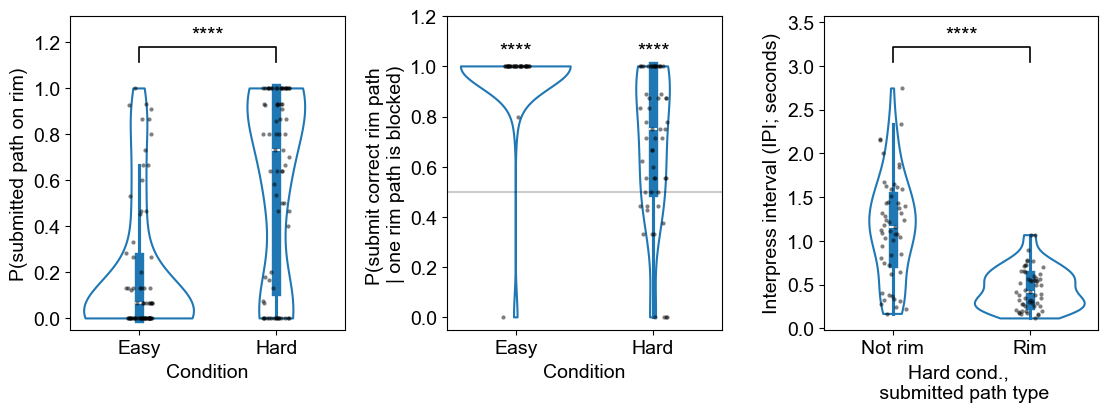

In [11]:
# Set the default font family to sans-serif
plt.rcParams['font.family'] = 'sans-serif'
# Specify Arial as the preferred sans-serif font
plt.rcParams['font.sans-serif'] = ['Arial']
# Set the default font size to 12
plt.rcParams['font.size'] = 14
cut=0
inner="box"

df_allsubjs_test_avg = df_allsubjs_test.groupby(['Subj','cond'], as_index=False)[["cond","first_cond","trajectory_length",
       "hit_wall", "reached_goal", "submitted_in_time", "trial_success",
       "trial_bonus","path_on_rim","full_path_on_rim", "rimpath_agreement", "rt", "first_rt", "submitted_path_avgrt"]].mean()
x_order = [0,1]

# Prepare figure
fig, ax = plt.subplots(1, 3, figsize=(13/1.15, 13/2.6/1.15))

# Shared orders

# Row 2
sns.violinplot(data=df_allsubjs_test_avg, x="cond", y="path_on_rim", cut=cut, inner=inner, fill=False, ax=ax[0])
sns.stripplot(data=df_allsubjs_test_avg, x="cond", y="path_on_rim", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[0])
# annotate: no hue
annotate_paired(
    ax=ax[0], df=df_allsubjs_test_avg,
    x="cond", y="path_on_rim", hue=None,
    pairs=[(0, 1)],
    order=x_order,
    text_offset=0.06
)
ax[0].set_xlim([-0.5,1.5])
ax[0].set_ylabel("P(submitted path on rim)")
ax[0].set_xlabel("Condition")
ax[0].set_xticklabels(["Easy","Hard"])

# Row 2
#df_temp = df_allsubjs_test[df_allsubjs_test["num_colors"]==8] # Only the num_colors = 8 condition?
df_temp = df_allsubjs_test.copy()

df_temp = df_temp[df_temp["path_on_rim"]==1] # Trials where participant used rim paths
df_temp = df_temp[df_temp["left_rim_path_open"] != df_temp["right_rim_path_open"]] # Trials where only one out of the two rim paths is open
df_temp = df_temp[~np.isnan(df_temp["path_taken_on_leftorrightrim"])]
df_temp["sensitive_to_whichrimopen"] = (df_temp["right_rim_path_open"]==df_temp["path_taken_on_leftorrightrim"]).astype(int) # For the above trials, did the subjects submit the (unique) open rim path? 
# Take mean over subjects
df_temp_avg = df_temp.groupby(['Subj',"cond"], as_index=False)[["Subj","first_cond","trajectory_length",
       "hit_wall", "reached_goal", "submitted_in_time", "trial_success",
       "trial_bonus","path_on_rim","full_path_on_rim", "rimpath_agreement", "rt", "first_rt", "submitted_path_rt", "submitted_path_presses", "submitted_path_avgrt","right_rim_path_open","path_taken_on_leftorrightrim","sensitive_to_whichrimopen"]].mean()
# print("P(choose correct rim path): {0} +- {1}".format(df_temp_avg["sensitive_to_whichrimopen"].mean(), df_temp_avg["sensitive_to_whichrimopen"].std()/np.sqrt(len(df_temp_avg))))
# print(df_temp_avg)


sns.violinplot(data=df_temp_avg, x="cond",y="sensitive_to_whichrimopen", cut=cut, inner=inner, fill=False, ax=ax[1])
sns.stripplot(data=df_temp_avg, x="cond",y="sensitive_to_whichrimopen", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[1])
annotate_violin_significance(
    ax=ax[1],
    df=df_temp_avg,
    x="cond",
    y="sensitive_to_whichrimopen",
    hue=None,
    test="t",            # "t" for one-sample t-test, "wilcoxon" for signed-rank
    mu=0.5,
    y_offset=0.02,
    min_height_pad=-0.1,
)
ax[1].plot([-1,2],[0.5,0.5],"k-",alpha=0.2)
ax[1].set_xlim([-0.5,1.5])
ax[1].set_ylim([None,1.2])
#ax[2].set_yticks([-0,0.5,1])
ax[1].set_ylabel("P(submit correct rim path \n| one rim path is blocked)")
ax[1].set_xlabel("Condition")
ax[1].set_xticklabels(["Easy","Hard"])

# Row 4
# For each subject x path_on_rim, this code averages over trials of both conditions.
df_allsubjs_test_avg = df_allsubjs_test.groupby(['Subj','path_on_rim'], as_index=False)[["cond","first_cond","trajectory_length",
       "hit_wall", "reached_goal", "submitted_in_time", "trial_success",
       "trial_bonus","path_on_rim","full_path_on_rim", "rimpath_agreement", "rt", "first_rt", "submitted_path_rt", "submitted_path_presses", "submitted_path_avgrt"]].mean()
df_allsubjs_test_avg_bycond = df_allsubjs_test.groupby(['Subj','cond','path_on_rim'], as_index=False)[["cond","first_cond","rt", "first_rt", "submitted_path_rt", "submitted_path_presses", "submitted_path_avgrt"]].mean()
df_temp = df_allsubjs_test_avg_bycond[df_allsubjs_test_avg_bycond["cond"]==1]
sns.violinplot(data=df_temp, x="path_on_rim", y="submitted_path_avgrt", cut=cut, inner=inner, fill=False, ax=ax[2])
sns.stripplot(data=df_temp, x="path_on_rim", y="submitted_path_avgrt", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[2])
# annotate: no hue
annotate_paired(
    ax=ax[2], df=df_temp,
    x="path_on_rim", y="submitted_path_avgrt", hue=None,
    pairs=[(0, 1)],
    order=x_order
)
ax[2].set_xlim([-0.5,1.5])
ax[2].set_ylabel("Interpress interval (IPI; seconds)")
ax[2].set_xlabel("Hard cond., \n submitted path type")
ax[2].set_xticklabels(["Not rim","Rim"])



# # Set titles
# ax[0].set(title=f"All participants; N={n_subj}")

fig.tight_layout()
# plt.savefig(os.path.join(figpath, "exp1_results"), dpi=300)
plt.savefig(os.path.join(figpath, "exp1_results.pdf"), bbox_inches='tight')
plt.show()

 comparison  n  df      t     p  cohen_dz
cond 0 vs 1 72  71 -7.193 0.000    -0.848
 comparison  n  df      t     p  cohen_dz
cond 0 vs 1 72  71 -5.933 0.000    -0.699
        comparison  n  df     t     p  cohen_dz
path_on_rim 0 vs 1 37  36 8.078 0.000     1.328


/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/1065744912.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["Easy","Hard"])
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/1065744912.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["Easy","Hard"])
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/1065744912.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(["Easy","Hard"])
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/1065744912.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(["Not ri

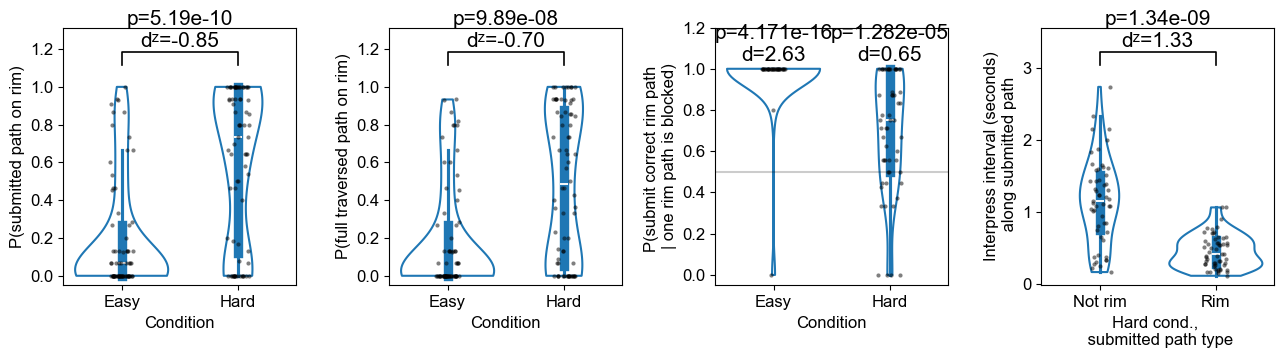

In [12]:
# Set the default font family to sans-serif
plt.rcParams['font.family'] = 'sans-serif'
# Specify Arial as the preferred sans-serif font
plt.rcParams['font.sans-serif'] = ['Arial']
# Set the default font size to 12
plt.rcParams['font.size'] = 12
cut=0

df_allsubjs_test_avg = df_allsubjs_test.groupby(['Subj','cond'], as_index=False)[["cond","first_cond","trajectory_length",
       "hit_wall", "reached_goal", "submitted_in_time", "trial_success",
       "trial_bonus","path_on_rim","full_path_on_rim", "rimpath_agreement", "rt", "first_rt", "submitted_path_avgrt"]].mean()
x_order = [0,1]

# Prepare figure
fig, ax = plt.subplots(1, 4, figsize=(13, 13/3.5))

# Shared orders

# Row 2
sns.violinplot(data=df_allsubjs_test_avg, x="cond", y="path_on_rim", cut=cut, fill=False, ax=ax[0])
sns.stripplot(data=df_allsubjs_test_avg, x="cond", y="path_on_rim", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[0])
# annotate: no hue
annotate_paired(
    ax=ax[0], df=df_allsubjs_test_avg,
    x="cond", y="path_on_rim", hue=None,
    pairs=[(0, 1)],
    order=x_order,
    text_offset=0.06,
    label='p_and_d',       # 'stars' | 'p' | 'p_and_d'
)
ax[0].set_xlim([-0.5,1.5])
ax[0].set_ylabel("P(submitted path on rim)")
ax[0].set_xlabel("Condition")
ax[0].set_xticklabels(["Easy","Hard"])

# Row 2
sns.violinplot(data=df_allsubjs_test_avg, x="cond", y="full_path_on_rim", cut=cut, fill=False, ax=ax[1])
sns.stripplot(data=df_allsubjs_test_avg, x="cond", y="full_path_on_rim", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[1])
# annotate: no hue
annotate_paired(
    ax=ax[1], df=df_allsubjs_test_avg,
    x="cond", y="full_path_on_rim", hue=None,
    pairs=[(0, 1)],
    order=x_order,
    text_offset=0.06,
    label='p_and_d',       # 'stars' | 'p' | 'p_and_d'
)
ax[1].set_xlim([-0.5,1.5])
ax[1].set_ylabel("P(full traversed path on rim)")
ax[1].set_xlabel("Condition")
ax[1].set_xticklabels(["Easy","Hard"])


# Row 3
#df_temp = df_allsubjs_test[df_allsubjs_test["num_colors"]==8] # Only the num_colors = 8 condition?
df_temp = df_allsubjs_test.copy()

df_temp = df_temp[df_temp["path_on_rim"]==1] # Trials where participant used rim paths
df_temp = df_temp[df_temp["left_rim_path_open"] != df_temp["right_rim_path_open"]] # Trials where only one out of the two rim paths is open
df_temp = df_temp[~np.isnan(df_temp["path_taken_on_leftorrightrim"])]
df_temp["sensitive_to_whichrimopen"] = (df_temp["right_rim_path_open"]==df_temp["path_taken_on_leftorrightrim"]).astype(int) # For the above trials, did the subjects submit the (unique) open rim path? 
# Take mean over subjects
df_temp_avg = df_temp.groupby(['Subj',"cond"], as_index=False)[["Subj","first_cond","trajectory_length",
       "hit_wall", "reached_goal", "submitted_in_time", "trial_success",
       "trial_bonus","path_on_rim","full_path_on_rim", "rimpath_agreement", "rt", "first_rt", "submitted_path_rt", "submitted_path_presses", "submitted_path_avgrt","right_rim_path_open","path_taken_on_leftorrightrim","sensitive_to_whichrimopen"]].mean()
# print("P(choose correct rim path): {0} +- {1}".format(df_temp_avg["sensitive_to_whichrimopen"].mean(), df_temp_avg["sensitive_to_whichrimopen"].std()/np.sqrt(len(df_temp_avg))))
# print(df_temp_avg)


sns.violinplot(data=df_temp_avg, x="cond",y="sensitive_to_whichrimopen", cut=cut, fill=False, ax=ax[2])
sns.stripplot(data=df_temp_avg, x="cond",y="sensitive_to_whichrimopen", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[2])
annotate_violin_significance(
    ax=ax[2],
    df=df_temp_avg,
    x="cond",
    y="sensitive_to_whichrimopen",
    hue=None,
    test="t",            # "t" for one-sample t-test, "wilcoxon" for signed-rank
    mu=0.5,
    y_offset=0.02,
    min_height_pad=-0.1,
    show='p_and_d',       # 'stars' | 'p' | 'p_and_d' 
)
ax[2].plot([-1,2],[0.5,0.5],"k-",alpha=0.2)
ax[2].set_xlim([-0.5,1.5])
ax[2].set_ylim([None,1.2])
#ax[2].set_yticks([-0,0.5,1])
ax[2].set_ylabel("P(submit correct rim path \n| one rim path is blocked)")
ax[2].set_xlabel("Condition")
ax[2].set_xticklabels(["Easy","Hard"])

# Row 4
# For each subject x path_on_rim, this code averages over trials of both conditions.
df_allsubjs_test_avg = df_allsubjs_test.groupby(['Subj','path_on_rim'], as_index=False)[["cond","first_cond","trajectory_length",
       "hit_wall", "reached_goal", "submitted_in_time", "trial_success",
       "trial_bonus","path_on_rim","full_path_on_rim", "rimpath_agreement", "rt", "first_rt", "submitted_path_rt", "submitted_path_presses", "submitted_path_avgrt"]].mean()
df_allsubjs_test_avg_bycond = df_allsubjs_test.groupby(['Subj','cond','path_on_rim'], as_index=False)[["cond","first_cond","rt", "first_rt", "submitted_path_rt", "submitted_path_presses", "submitted_path_avgrt"]].mean()
df_temp = df_allsubjs_test_avg_bycond[df_allsubjs_test_avg_bycond["cond"]==1]
sns.violinplot(data=df_temp, x="path_on_rim", y="submitted_path_avgrt", cut=cut, fill=False, ax=ax[3])
sns.stripplot(data=df_temp, x="path_on_rim", y="submitted_path_avgrt", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[3])
# annotate: no hue
annotate_paired(
    ax=ax[3], df=df_temp,
    x="path_on_rim", y="submitted_path_avgrt", hue=None,
    pairs=[(0, 1)],
    order=x_order,
    label='p_and_d',       # 'stars' | 'p' | 'p_and_d'
)
ax[3].set_xlim([-0.5,1.5])
ax[3].set_ylabel("Interpress interval (seconds)\n along submitted path")
ax[3].set_xlabel("Hard cond., \n submitted path type")
ax[3].set_xticklabels(["Not rim","Rim"])



# # Set titles
# ax[0].set(title=f"All participants; N={n_subj}")

fig.tight_layout()
# plt.savefig(os.path.join(figpath, "exp1_results_pvals"), dpi=300)
# plt.savefig(os.path.join(figpath, "exp1_results_pvals.pdf"), bbox_inches='tight')
plt.show()

# Sanity check figures

In [19]:
def annotate_paired(
    ax, df, x, y, hue=None, pairs=None,
    order=None, hue_order=None,
    cat_width=0.8,       # match seaborn's violinplot width
    text_offset=0.06,    # fraction of y-range between brackets
    linewidth=1.2, fontsize=15,
    label='stars',       # 'stars' | 'p' | 'p_and_d'
    test_type = "paired-t", # "paired-t" | "wilcoxon"
    print_table=True,    # print a table of results
    return_table=False,  # return the results DataFrame
    decimals=3           # rounding in printed table
):
    """
    Draw paired t-test brackets and (optionally) print/return stats.
    If hue is None: pairs = [(x1, x2), ...]
    If hue is not None: pairs = [((x1,h1),(x2,h2)), ...]

    Effect size reported: Cohen's dz = mean(diff)/sd(diff), paired design.
    """
    # Ensure Subject column for pairing
    if 'Subj' not in df.columns:
        df = df.reset_index()

    # Resolve plotting orders
    if order is None:
        order = list(pd.unique(df[x]))
    if hue is not None and hue_order is None:
        hue_order = list(pd.unique(df[hue]))

    # ---- centers that match split-violins exactly ----
    if hue is None:
        offset_map = {None: 0.0}
    else:
        k = len(hue_order)
        cell = cat_width / float(k)  # width per split violin
        centers = np.linspace(-cat_width/2 + cell/2,
                              +cat_width/2 - cell/2, k)
        offset_map = {h: centers[i] for i, h in enumerate(hue_order)}

    def xpos(x_level, h_level=None):
        xi = order.index(x_level)
        return xi + (offset_map[None] if hue is None else offset_map[h_level])

    # ---- compute stats for each pair ----
    rows = []
    for pr in pairs:
        if hue is None:
            x1, x2 = pr
            d1 = df[df[x] == x1][['Subj', y]].rename(columns={y:'v1'})
            d2 = df[df[x] == x2][['Subj', y]].rename(columns={y:'v2'})
            lab = f"{x} {x1} vs {x2}"
        else:
            (x1, h1), (x2, h2) = pr
            d1 = df[(df[x] == x1) & (df[hue] == h1)][['Subj', y]].rename(columns={y:'v1'})
            d2 = df[(df[x] == x2) & (df[hue] == h2)][['Subj', y]].rename(columns={y:'v2'})
            lab = f"({x1},{h1}) vs ({x2},{h2})"

        merged = pd.merge(d1, d2, on='Subj').dropna(subset=['v1','v2'])
        n = len(merged)
        if n >= 2:
            diff = (merged['v1'] - merged['v2']).to_numpy(dtype=float)
            sd = np.std(diff, ddof=1)
            dz = np.nan if sd == 0 else np.mean(diff) / sd
            if(test_type=="paired-t"):
                t_stat, p = ttest_rel(merged['v1'], merged['v2'])
            elif(test_type=="wilcoxon"):
                t_stat, p = wilcoxon(merged['v1'], merged['v2'])
            dfree = n - 1
        else:
            t_stat = p = dz = np.nan
            dfree = n - 1

        rows.append({
            'comparison': lab, 'n': n, 'df': dfree,
            't': t_stat, 'p': p, 'cohen_dz': dz
        })

    results = pd.DataFrame(rows)

    # ---- vertical layout & draw ----
    ymin, ymax = ax.get_ylim()
    yr = max(ymax - ymin, 1e-9)
    step = text_offset * yr
    ax.set_ylim(ymin, ymax + step * (len(pairs)*3 + 1))

    for i, pr in enumerate(pairs):
        if hue is None:
            x1, x2 = pr
            x1p, x2p = xpos(x1), xpos(x2)
        else:
            (x1, h1), (x2, h2) = pr
            x1p, x2p = xpos(x1, h1), xpos(x2, h2)

        stats = results.iloc[i]
        p = stats['p']; dz = stats['cohen_dz']

        # label text
        if label == 'stars':
            if   np.isnan(p): s = 'n/a'
            elif p < 1e-4:    s = '****'
            elif p < 1e-3:    s = '***'
            elif p < 1e-2:    s = '**'
            elif p < 5e-2:    s = '*'
            else:             s = 'n.s.'
        elif label == 'p':
            s = f"p={p:.3g}" if not np.isnan(p) else "p=n/a"
        elif label == 'p_and_d':
            sp = f"p={p:.3g}" if not np.isnan(p) else "p=n/a"
            sd = f"dᶻ={dz:.2f}" if not np.isnan(dz) else "dᶻ=n/a"
            s = sp + "\n" + sd
        else:
            s = ''

        # bracket height for this pair
        yb = ymax + step * (i*3 + 1)
        ytop = yb + step

        ax.plot([x1p, x1p, x2p, x2p], [yb, ytop, ytop, yb],
                'k-', lw=linewidth, clip_on=False)
        ax.text((x1p+x2p)/2.0, ytop + 0.12*step, s,
                ha='center', va='bottom', fontsize=fontsize, clip_on=False)

    # ---- print & return ----
    if print_table:
        with pd.option_context('display.float_format', lambda v: f"{v:.{decimals}f}"):
            print(results.to_string(index=False))

    if return_table:
        return results

        


 comparison  n  df      t     p  cohen_dz
cond 0 vs 1 72  71 10.713 0.000     1.263
 comparison  n  df      t     p  cohen_dz
cond 0 vs 1 72  71 -7.193 0.000    -0.848
 comparison  n  df      t     p  cohen_dz
cond 0 vs 1 72  71 -5.933 0.000    -0.699
 comparison  n  df      t     p  cohen_dz
cond 0 vs 1 72  71 -7.460 0.000    -0.879
 comparison  n  df      t     p  cohen_dz
cond 0 vs 1 72  71 -5.595 0.000    -0.659
        comparison  n  df     t     p  cohen_dz
(0,0.0) vs (1,0.0) 36  35 7.240 0.000     1.207
(0,1.0) vs (1,1.0) 36  35 7.983 0.000     1.330
        comparison  n  df      t     p  cohen_dz
(0,0.0) vs (1,0.0) 36  35 -6.549 0.000    -1.091
(0,1.0) vs (1,1.0) 36  35 -3.978 0.000    -0.663
        comparison  n  df      t     p  cohen_dz
(0,0.0) vs (1,0.0) 36  35 -5.638 0.000    -0.940
(0,1.0) vs (1,1.0) 36  35 -2.966 0.005    -0.494
        comparison  n  df      t     p  cohen_dz
(0,0.0) vs (1,0.0) 36  35 -3.654 0.001    -0.609
(0,1.0) vs (1,1.0) 36  35 -7.290 0.000    -1

/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/761870154.py:81: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  g=sns.stripplot(
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/761870154.py:91: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  g=sns.stripplot(
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/761870154.py:101: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  g=sns.stripplot(
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/761870154.py:111: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  g=sns.stripplot(
/v

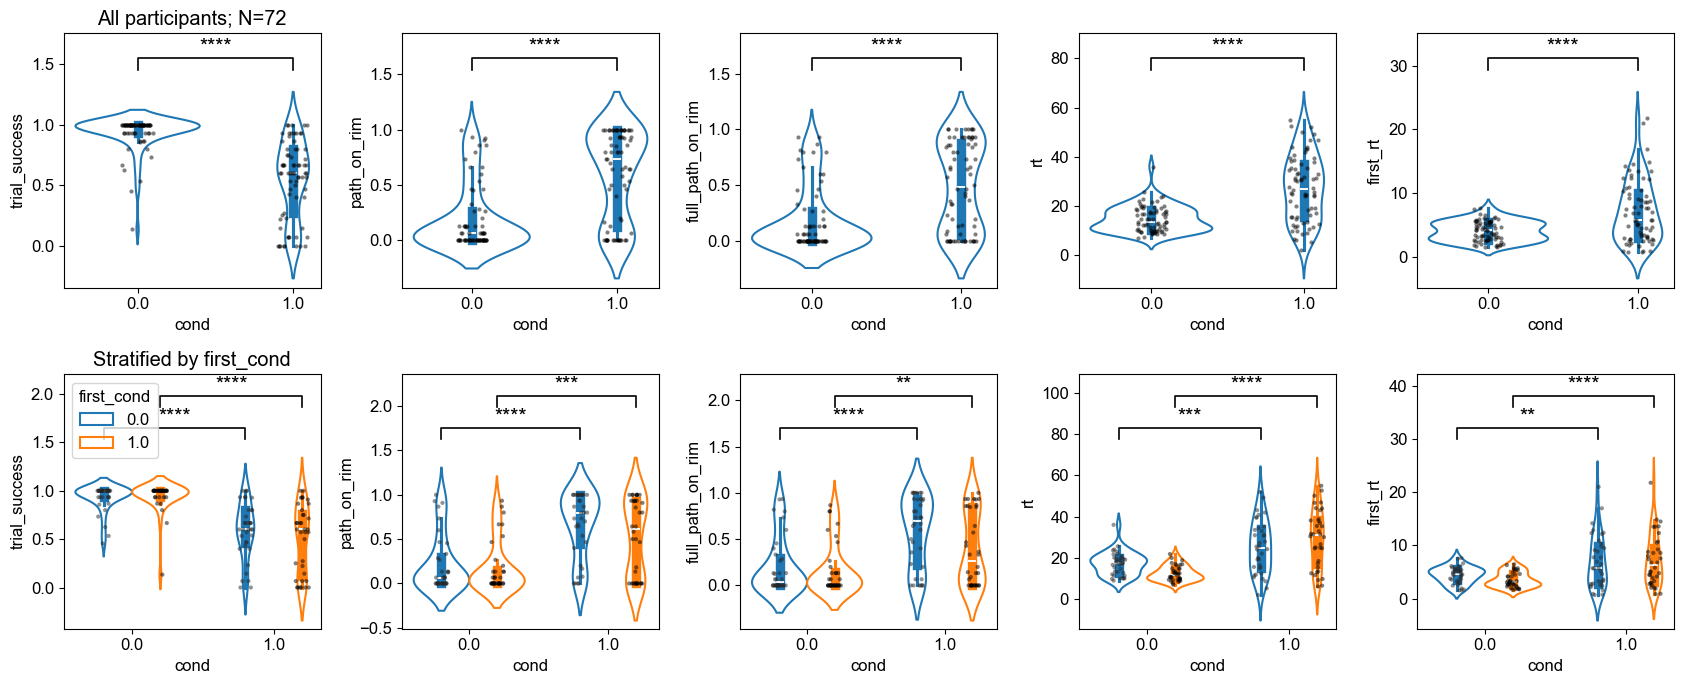

In [20]:
df_allsubjs_test_avg = df_allsubjs_test.groupby(['Subj','num_colors'], as_index=False)[["cond","first_cond","trajectory_length",
       "hit_wall", "reached_goal", "submitted_in_time", "trial_success",
       "trial_bonus","path_on_rim","full_path_on_rim", "rimpath_agreement", "rt", "first_rt", "submitted_path_avgrt"]].mean()

x_order = [0,1]

# Prepare figure
fig, ax = plt.subplots(2, 5, figsize=(17, 7))

# Shared orders
# Row 1
sns.violinplot(data=df_allsubjs_test_avg, x="cond", y="trial_success", fill=False, ax=ax[0,0])
sns.stripplot(data=df_allsubjs_test_avg, x="cond", y="trial_success", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[0,0])
# annotate: no hue
annotate_paired(
    ax=ax[0,0], df=df_allsubjs_test_avg,
    x="cond", y="trial_success", hue=None,
    pairs=[(0, 1)],
    order=x_order,
    text_offset=0.06
)

# Row 2
sns.violinplot(data=df_allsubjs_test_avg, x="cond", y="path_on_rim", fill=False, ax=ax[0,1])
sns.stripplot(data=df_allsubjs_test_avg, x="cond", y="path_on_rim", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[0,1])
# annotate: no hue
annotate_paired(
    ax=ax[0,1], df=df_allsubjs_test_avg,
    x="cond", y="path_on_rim", hue=None,
    pairs=[(0, 1)],
    order=x_order,
    text_offset=0.06
)

# Row 3
sns.violinplot(data=df_allsubjs_test_avg, x="cond", y="full_path_on_rim", fill=False, ax=ax[0,2])
sns.stripplot(data=df_allsubjs_test_avg, x="cond", y="full_path_on_rim", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[0,2])

# annotate: no hue
annotate_paired(
    ax=ax[0,2], df=df_allsubjs_test_avg,
    x="cond", y="full_path_on_rim", hue=None,
    pairs=[(0, 1)],
    order=x_order
)

# Row 4
sns.violinplot(data=df_allsubjs_test_avg, x="cond", y="rt", fill=False, ax=ax[0,3])
sns.stripplot(data=df_allsubjs_test_avg, x="cond", y="rt", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[0,3])

# annotate: no hue
annotate_paired(
    ax=ax[0,3], df=df_allsubjs_test_avg,
    x="cond", y="rt", hue=None,
    pairs=[(0, 1)],
    order=x_order
)

# Row 5
sns.violinplot(data=df_allsubjs_test_avg, x="cond", y="first_rt", fill=False, ax=ax[0,4])
sns.stripplot(data=df_allsubjs_test_avg, x="cond", y="first_rt", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[0,4])

# annotate: no hue
annotate_paired(
    ax=ax[0,4], df=df_allsubjs_test_avg,
    x="cond", y="first_rt", hue=None,
    pairs=[(0, 1)],
    order=x_order
)

# ===== Row 2: with hue = first_cond =====
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="cond", y="trial_success", hue="first_cond", fill=False, ax=ax[1,0]
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="cond", y="trial_success", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,0]
)
# Row 2
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="cond", y="path_on_rim", hue="first_cond", fill=False, ax=ax[1,1], legend=False
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="cond", y="path_on_rim", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,1]
)
# Row 3
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="cond", y="full_path_on_rim", hue="first_cond", fill=False, ax=ax[1,2], legend=False
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="cond", y="full_path_on_rim", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,2]
)
# Row 4
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="cond", y="rt", hue="first_cond", fill=False, ax=ax[1,3], legend=False
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="cond", y="rt", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,3]
)
# Row 5
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="cond", y="first_rt", hue="first_cond", fill=False, ax=ax[1,4], legend=False
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="cond", y="first_rt", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,4]
)

x_order = [0, 1]
h_order = sorted(df_allsubjs_test_avg['first_cond'].dropna().unique().tolist())

def four_pairs(x_order, h_order):
#     # (1) within each cond: compare hues// Can't do this because paired t-test is within-subject
#     within_cond = [((x, h_order[0]), (x, h_order[1])) for x in x_order]
    # (2) within each hue: compare conds
    within_hue  = [((x_order[0], h), (x_order[1], h)) for h in h_order]
    # return within_cond + within_hue
    return within_hue

# Example for path_on_rim on row 2
pairs4 = four_pairs(x_order, h_order)

for j, (yy, ax_here) in enumerate([
    ('trial_success',    ax[1,0]),
    ('path_on_rim',      ax[1,1]),
    ('full_path_on_rim', ax[1,2]),
    ('rt',               ax[1,3]),
    ('first_rt',               ax[1,4]),
]):
    annotate_paired(
        ax=ax_here, df=df_allsubjs_test_avg,
        x="cond", y=yy, hue="first_cond",
        pairs=pairs4,
        order=x_order, hue_order=h_order,
        cat_width=0.8,      # match your seaborn violin width
        text_offset=0.06    # tweak if you need more spacing
    )
    
    
# Set titles
ax[0,0].set(title=f"All participants; N={n_subj}")
ax[1,0].set(title=f"Stratified by first_cond")

fig.tight_layout()
#plt.savefig(os.path.join(figpath, "exp1_pairedt_exclusion"), dpi=300)
plt.show()

## II) IPI results

        comparison  n  df      t     p  cohen_dz
path_on_rim 0 vs 1 63  62 -1.640 0.106    -0.207
        comparison  n  df      t     p  cohen_dz
path_on_rim 0 vs 1 63  62 -4.757 0.000    -0.599
        comparison  n  df       t     p  cohen_dz
path_on_rim 0 vs 1 63  62 -22.743 0.000    -2.865
        comparison  n  df       t     p  cohen_dz
path_on_rim 0 vs 1 63  62 -13.928 0.000    -1.755
        comparison  n  df     t     p  cohen_dz
path_on_rim 0 vs 1 63  62 6.325 0.000     0.797
        comparison  n  df      t     p  cohen_dz
(0,0.0) vs (1,0.0) 32  31 -0.876 0.388    -0.155
(0,1.0) vs (1,1.0) 31  30 -1.423 0.165    -0.255
        comparison  n  df      t     p  cohen_dz
(0,0.0) vs (1,0.0) 32  31 -3.107 0.004    -0.549
(0,1.0) vs (1,1.0) 31  30 -3.654 0.001    -0.656
        comparison  n  df       t     p  cohen_dz
(0,0.0) vs (1,0.0) 32  31 -17.266 0.000    -3.052
(0,1.0) vs (1,1.0) 31  30 -14.853 0.000    -2.668
        comparison  n  df       t     p  cohen_dz
(0,0.0) vs (1,

/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/2592477177.py:87: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  g=sns.stripplot(
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/2592477177.py:97: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  g=sns.stripplot(
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/2592477177.py:107: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  g=sns.stripplot(
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_81063/2592477177.py:117: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  g=sns.stripplot

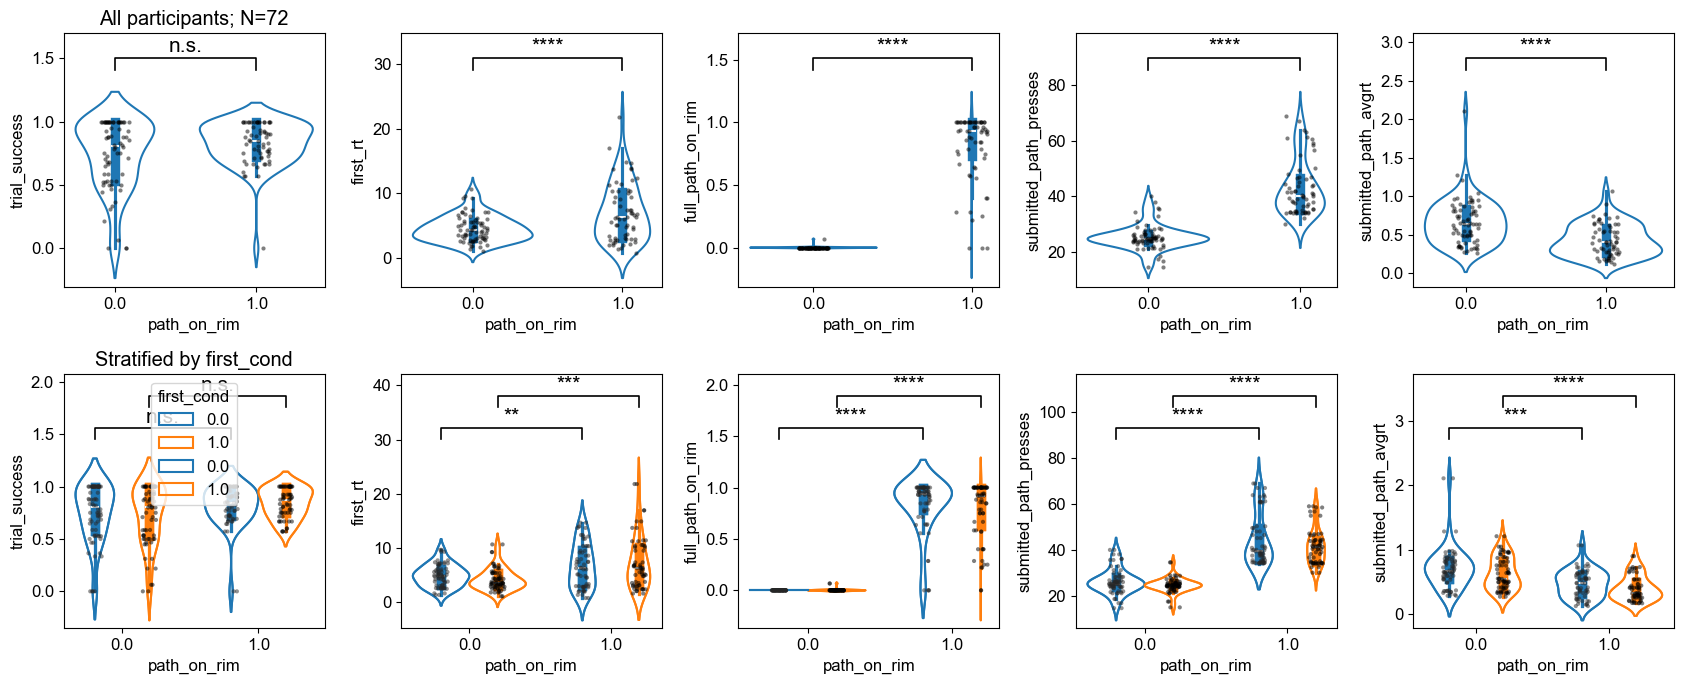

In [21]:
# New visualization: stratify not by condition, but by whether a rim path is submitted for each trial.
# Col 5 is most informative: solution verification should lead to shorter RTs when implementing the solution via WASDB! 
#                            This is because subjects are not planning the next steps as they go (which incurrs longer RTs)
# Our hypothesis is valid! See significant differences in Col 5. 

# For each subject x path_on_rim, this code averages over trials of both conditions.
df_allsubjs_test_avg = df_allsubjs_test.groupby(['Subj','path_on_rim'], as_index=False)[["cond","first_cond","trajectory_length",
       "hit_wall", "reached_goal", "submitted_in_time", "trial_success",
       "trial_bonus","path_on_rim","full_path_on_rim", "rimpath_agreement", "rt", "first_rt", "submitted_path_rt", "submitted_path_presses", "submitted_path_avgrt"]].mean()

x_order = [0,1]

# Prepare figure
fig, ax = plt.subplots(2, 5, figsize=(17, 7))

# Shared orders
# Row 1
sns.violinplot(data=df_allsubjs_test_avg, x="path_on_rim", y="trial_success", fill=False, ax=ax[0,0])
sns.stripplot(data=df_allsubjs_test_avg, x="path_on_rim", y="trial_success", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[0,0])
# annotate: no hue
annotate_paired(
    ax=ax[0,0], df=df_allsubjs_test_avg,
    x="path_on_rim", y="trial_success", hue=None,
    pairs=[(0, 1)],
    order=x_order,
    text_offset=0.06
)

# Row 2
sns.violinplot(data=df_allsubjs_test_avg, x="path_on_rim", y="first_rt", fill=False, ax=ax[0,1])
sns.stripplot(data=df_allsubjs_test_avg, x="path_on_rim", y="first_rt", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[0,1])
# annotate: no hue
annotate_paired(
    ax=ax[0,1], df=df_allsubjs_test_avg,
    x="path_on_rim", y="first_rt", hue=None,
    pairs=[(0, 1)],
    order=x_order,
    text_offset=0.06
)

# Row 3
sns.violinplot(data=df_allsubjs_test_avg, x="path_on_rim", y="full_path_on_rim", fill=False, ax=ax[0,2])
sns.stripplot(data=df_allsubjs_test_avg, x="path_on_rim", y="full_path_on_rim", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[0,2])

# annotate: no hue
annotate_paired(
    ax=ax[0,2], df=df_allsubjs_test_avg,
    x="path_on_rim", y="full_path_on_rim", hue=None,
    pairs=[(0, 1)],
    order=x_order
)

# Row 4
sns.violinplot(data=df_allsubjs_test_avg, x="path_on_rim", y="submitted_path_presses", fill=False, ax=ax[0,3])
sns.stripplot(data=df_allsubjs_test_avg, x="path_on_rim", y="submitted_path_presses", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[0,3])

# annotate: no hue
annotate_paired(
    ax=ax[0,3], df=df_allsubjs_test_avg,
    x="path_on_rim", y="submitted_path_presses", hue=None,
    pairs=[(0, 1)],
    order=x_order
)

# Row 5
sns.violinplot(data=df_allsubjs_test_avg, x="path_on_rim", y="submitted_path_avgrt", fill=False, ax=ax[0,4])
sns.stripplot(data=df_allsubjs_test_avg, x="path_on_rim", y="submitted_path_avgrt", dodge=True,
              color="k", alpha=0.5, size=3, legend=False, ax=ax[0,4])

# annotate: no hue
annotate_paired(
    ax=ax[0,4], df=df_allsubjs_test_avg,
    x="path_on_rim", y="submitted_path_avgrt", hue=None,
    pairs=[(0, 1)],
    order=x_order
)

# ===== Row 2: with hue = first_cond =====
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="trial_success", hue="first_cond", fill=False, ax=ax[1,0]
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="trial_success", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,0]
)
# Row 2
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="first_rt", hue="first_cond", fill=False, ax=ax[1,1], legend=False
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="first_rt", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,1]
)
# Row 3
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="full_path_on_rim", hue="first_cond", fill=False, ax=ax[1,2], legend=False
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="full_path_on_rim", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,2]
)
# Row 4
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="submitted_path_presses", hue="first_cond", fill=False, ax=ax[1,3], legend=False
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="submitted_path_presses", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,3]
)
# Row 5
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="submitted_path_avgrt", hue="first_cond", fill=False, ax=ax[1,4], legend=False
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="submitted_path_avgrt", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,4]
)


# ===== Row 2: with hue = first_cond =====
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="trial_success", hue="first_cond", fill=False, ax=ax[1,0]
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="trial_success", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,0]
)
# Row 2
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="first_rt", hue="first_cond", fill=False, ax=ax[1,1], legend=False
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="first_rt", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,1]
)
# Row 3
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="full_path_on_rim", hue="first_cond", fill=False, ax=ax[1,2], legend=False
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="full_path_on_rim", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,2]
)
# Row 4
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="submitted_path_presses", hue="first_cond", fill=False, ax=ax[1,3], legend=False
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="submitted_path_presses", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,3]
)
# Row 5
g=sns.violinplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="submitted_path_avgrt", hue="first_cond", fill=False, ax=ax[1,4], legend=False
)
g=sns.stripplot(
    data=df_allsubjs_test_avg,
    x="path_on_rim", y="submitted_path_avgrt", hue="first_cond", dodge=True,
    color="k", alpha=0.5, size=3, legend=False, ax=ax[1,4]
)

x_order = [0, 1]
h_order = sorted(df_allsubjs_test_avg['first_cond'].dropna().unique().tolist())

def four_pairs(x_order, h_order):
#     # (1) within each cond: compare hues// Can't do this because paired t-test is within-subject
#     within_cond = [((x, h_order[0]), (x, h_order[1])) for x in x_order]
    # (2) within each hue: compare conds
    within_hue  = [((x_order[0], h), (x_order[1], h)) for h in h_order]
    # return within_cond + within_hue
    return within_hue

# Example for path_on_rim on row 2
pairs4 = four_pairs(x_order, h_order)

for j, (yy, ax_here) in enumerate([
    ('trial_success',    ax[1,0]),
    ('first_rt',      ax[1,1]),
    ('full_path_on_rim', ax[1,2]),
    ('submitted_path_presses',               ax[1,3]),
    ('submitted_path_avgrt',               ax[1,4]),
]):
    annotate_paired(
        ax=ax_here, df=df_allsubjs_test_avg,
        x="path_on_rim", y=yy, hue="first_cond",
        pairs=pairs4,
        order=x_order, hue_order=h_order,
        cat_width=0.8,      # match your seaborn violin width
        text_offset=0.06    # tweak if you need more spacing
    )

    
# Set titles
ax[0,0].set(title=f"All participants; N={n_subj}")
ax[1,0].set(title=f"Stratified by first_cond")

fig.tight_layout()
#plt.savefig(os.path.join(figpath, "exp1_pilot1_pairedt_stratbypathonrim"), dpi=300)
plt.show()

In [22]:
# Do this comparison for num_colors=8 condition only, because that is of interest.
df_allsubjs_test_avg = df_allsubjs_test.groupby(['Subj','cond','path_on_rim'], as_index=False)[["cond","first_cond","trajectory_length",
       "hit_wall", "reached_goal", "submitted_in_time", "trial_success",
       "trial_bonus","path_on_rim","full_path_on_rim", "rimpath_agreement", "rt", "first_rt", "submitted_path_rt", "submitted_path_presses", "submitted_path_avgrt"]].mean()
df_allsubjs_test_avg
df_temp = df_allsubjs_test_avg[df_allsubjs_test_avg["cond"]==1]
df = df_temp.dropna(subset=["Subj", "path_on_rim", "submitted_path_avgrt"]).copy()

# Make sure path_on_rim is coded as 0/1
df = df[df["path_on_rim"].isin([0, 1])]

# Subject-level means for each condition
subj_means = (
    df.groupby(["Subj", "path_on_rim"])["submitted_path_avgrt"]
      .mean()
      .unstack("path_on_rim")
)

# Rename columns for clarity
subj_means = subj_means.rename(columns={0: "non_rim", 1: "rim"})

# Keep only subjects who have both path_on_rim == 0 and path_on_rim == 1
paired = subj_means.dropna(subset=["non_rim", "rim"])

# Paired t-test: rim vs non-rim
tres = stats.ttest_rel(paired["rim"], paired["non_rim"])

print(f"N paired subjects: {len(paired)}")
print(f"Mean rim: {paired['rim'].mean():.4f} +- {paired['rim'].sem(ddof=1):.4f}")
print(f"Mean non-rim: {paired['non_rim'].mean():.4f} +- {paired['non_rim'].sem(ddof=1):.4f}")
print(f"Mean diff rim - non-rim: {(paired['rim'] - paired['non_rim']).mean():.4f}")
print(f"Paired t-test: t = {tres.statistic:.4f}, p = {tres.pvalue:.6g}")

diff = paired["rim"] - paired["non_rim"]
dz = diff.mean() / diff.std(ddof=1)

print(f"Cohen's dz: {dz:.4f}")

excluded = subj_means[subj_means[["non_rim", "rim"]].isna().any(axis=1)]
print(f"N excluded subjects: {len(excluded)}")

N paired subjects: 37
Mean rim: 0.4735 +- 0.0359
Mean non-rim: 1.1441 +- 0.0928
Mean diff rim - non-rim: -0.6706
Paired t-test: t = -8.0775, p = 1.33865e-09
Cohen's dz: -1.3279
N excluded subjects: 35


# Could the JIT model capture the rim path reuse pattern in humans? 
## One example simulation only


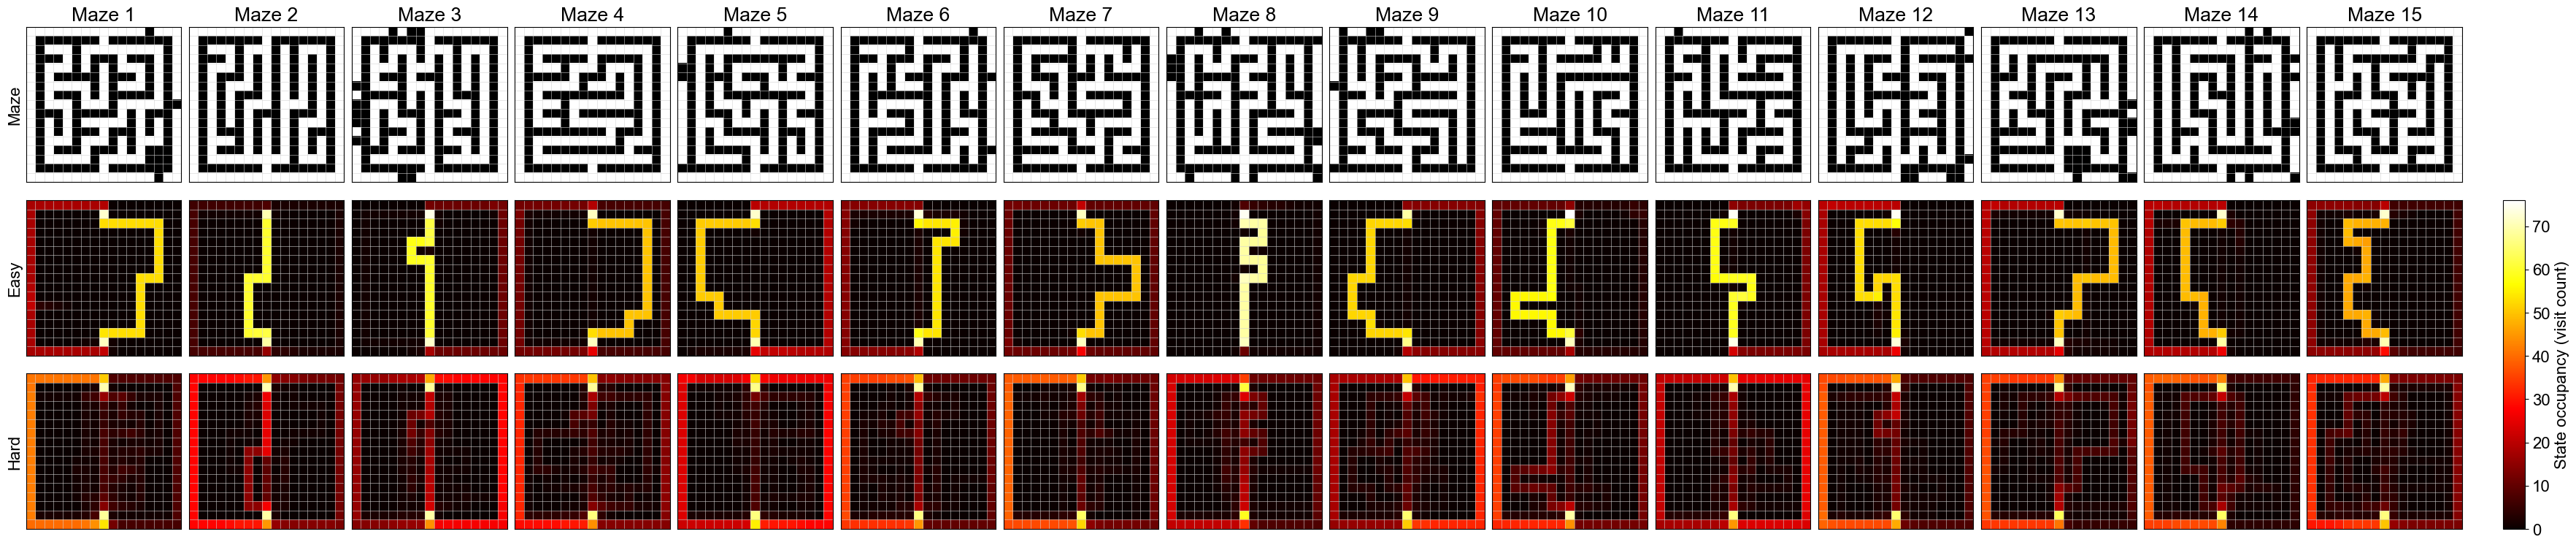

In [24]:
# Human heatmaps
plt.rcParams.update({'font.size': 16})


magnify = 2.5
condition_names = ["Easy", "Hard"]
colorbar_mode = "shared"   # "shared" or "each"

# dataframe column names
subj_col = "Subj"
maze_col = "test_maze_orig_idx"
trajectory_col = "trajectory_parsed"
condition_col = "cond"
easy_value = 0
hard_value = 1

# set depending on your coordinate convention
swap_xy = True

# if True: each subject contributes at most 1 per visited cell
# if False: repeated visits count multiple times
binary_per_subject = False


# =========================================================
# Helpers
# =========================================================
def maze_to_char_array(maze):
    return np.array([list(row) for row in maze])


def occupancy_from_path_list(path_list, maze_shape, swap_xy=False, binary_per_subject=False):
    occ = np.zeros(maze_shape, dtype=float)

    for path in path_list:
        subj_occ = np.zeros(maze_shape, dtype=float)

        for pos in path:
            x, y = pos[:2]
            x = int(x)
            y = int(y)

            if swap_xy:
                rr, cc = y, x
            else:
                rr, cc = x, y

            if 0 <= rr < maze_shape[0] and 0 <= cc < maze_shape[1]:
                if binary_per_subject:
                    subj_occ[rr, cc] = 1
                else:
                    subj_occ[rr, cc] += 1

        occ += subj_occ

    return occ


def make_maze_background(maze_arr):
    """
    Top-row maze rendering only.
    wall(#) -> black
    everything else -> white
    """
    bg = np.ones(maze_arr.shape, dtype=float)
    bg[maze_arr == '#'] = 0.0
    return bg


def draw_maze_layout(ax, maze_arr, title=None):
    bg = make_maze_background(maze_arr)
    ax.imshow(bg, cmap="gray", origin="upper", interpolation="none")

    ax.set_xticks(np.arange(-0.5, maze_arr.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, maze_arr.shape[0], 1), minor=True)
    ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)

    ax.tick_params(
        which='both',
        bottom=False, left=False,
        labelbottom=False, labelleft=False
    )

    if title is not None:
        ax.set_title(title)


def draw_heatmap(ax, maze_arr, occ, ylabel=None, vmin=None, vmax=None, fontsize=12):
    """
    Pure heatmap: no maze masking / no wall blackout.
    """
    hm = ax.imshow(
        occ,
        cmap="hot",
        origin="upper",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xticks(np.arange(-0.5, maze_arr.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, maze_arr.shape[0], 1), minor=True)
    ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)

    ax.tick_params(
        which='both',
        bottom=False, left=False,
        labelbottom=False, labelleft=False
    )

    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=fontsize)

    return hm


# =========================================================
# Build pooled occupancy maps from df_allsubjs_test
# =========================================================
df_plot = df_allsubjs_test.copy()

required_cols = [subj_col, maze_col, trajectory_col, condition_col]
missing = [c for c in required_cols if c not in df_plot.columns]
if len(missing) > 0:
    raise ValueError(f"Missing required columns: {missing}")

df_plot = df_plot[required_cols].copy()
df_plot = df_plot[df_plot[condition_col].isin([easy_value, hard_value])].copy()
df_plot = df_plot[df_plot[trajectory_col].notna()].copy()

maze_ids = sorted(df_plot[maze_col].dropna().unique())
n_maze = len(maze_ids)

maze_arrays = []
occupancies_easy = []
occupancies_hard = []

for maze_idx in maze_ids:
    maze_arr = maze_to_char_array(test_mazes[int(maze_idx)])
    maze_shape = maze_arr.shape

    df_maze = df_plot[df_plot[maze_col] == maze_idx]

    paths_easy = df_maze.loc[df_maze[condition_col] == easy_value, trajectory_col].tolist()
    paths_hard = df_maze.loc[df_maze[condition_col] == hard_value, trajectory_col].tolist()

    occ_easy = occupancy_from_path_list(
        paths_easy, maze_shape,
        swap_xy=swap_xy,
        binary_per_subject=binary_per_subject
    )
    occ_hard = occupancy_from_path_list(
        paths_hard, maze_shape,
        swap_xy=swap_xy,
        binary_per_subject=binary_per_subject
    )

    maze_arrays.append(maze_arr)
    occupancies_easy.append(occ_easy)
    occupancies_hard.append(occ_hard)

# shared scale if requested
global_vmax = max(
    max(np.max(x) for x in occupancies_easy) if len(occupancies_easy) > 0 else 0,
    max(np.max(x) for x in occupancies_hard) if len(occupancies_hard) > 0 else 0
)



# =========================================================
# Plot: top row maze, second easy, third hard
# =========================================================

# Set the global font size for all text elements
plt.rcParams.update({'font.size': 16})


n_rows_total = 3

# Smaller value = tighter vertical spacing between rows
row_gap = 0.05   # try 0.00, -0.02, or -0.05

fig, ax = plt.subplots(
    n_rows_total,
    n_maze,
    figsize=(n_maze * magnify, n_rows_total * magnify * 1.05),
    gridspec_kw={
        "wspace": 0.05,
        "hspace": row_gap
    },
    constrained_layout=False
)

if n_maze == 1:
    ax = np.array(ax).reshape(n_rows_total, 1)

# -------------------------
# Top row: actual maze layouts
# -------------------------
for col_idx, maze_idx in enumerate(maze_ids):
    draw_maze_layout(
        ax[0, col_idx],
        maze_arrays[col_idx],
        title=f"Maze {int(maze_idx+1)}"
    )
    if col_idx == 0:
        ax[0, col_idx].set_ylabel("Maze")

# -------------------------
# Bottom rows: pooled heatmaps
# -------------------------
all_hm = []

for col_idx, maze_idx in enumerate(maze_ids):
    maze_arr = maze_arrays[col_idx]
    occs = [occupancies_easy[col_idx], occupancies_hard[col_idx]]

    for cond_idx, occ in enumerate(occs):
        cur_ax = ax[1 + cond_idx, col_idx]

        if colorbar_mode == "shared":
            hm = draw_heatmap(
                cur_ax,
                maze_arr,
                occ,
                ylabel=condition_names[cond_idx] if col_idx == 0 else None,
                vmin=0,
                vmax=global_vmax,
                fontsize=16,
            )
        elif colorbar_mode == "each":
            local_vmax = np.max(occ)
            hm = draw_heatmap(
                cur_ax,
                maze_arr,
                occ,
                ylabel=condition_names[cond_idx] if col_idx == 0 else None,
                vmin=0,
                vmax=local_vmax if local_vmax > 0 else 1,
                fontsize=16
            )
            cbar = fig.colorbar(hm, ax=cur_ax, shrink=0.85, pad=0.01)
            if binary_per_subject:
                cbar.set_label("N subjects")
            else:
                cbar.set_label("Visit count")
        else:
            raise ValueError("colorbar_mode must be 'shared' or 'each'")

        all_hm.append(hm)

# Fine manual adjustment first: leave room on right for shared colorbar
fig.subplots_adjust(
    left=0.03,
    right=0.92,
    bottom=0.03,
    top=0.92,
    wspace=0.0,
    hspace=row_gap
)

# Shared colorbar: manually place it next to the last two rows only
if colorbar_mode == "shared":
    bottom_pos = ax[2, -1].get_position()
    top_pos = ax[1, -1].get_position()

    cbar_x = 0.935
    cbar_y = bottom_pos.y0
    cbar_width = 0.008
    cbar_height = top_pos.y1 - bottom_pos.y0

    cbar_ax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_height])
    cbar = fig.colorbar(all_hm[-1], cax=cbar_ax)

    if binary_per_subject:
        cbar.set_label("State occupancy (N subjects)")
    else:
        cbar.set_label("State occupancy (visit count)")

# fig.suptitle(
#     "Maze layouts and pooled occupancy heatmaps from df_allsubjs_test",
#     y=0.975
# )

fname = f"exp1_occupancy_heatmaps_human-{colorbar_mode}"
# plt.savefig(os.path.join(figpath, fname + ".png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figpath, fname + ".pdf"), bbox_inches="tight")
plt.show()

## Reparse mazes to be compatible with JIT model functions

In [26]:

def location_on_shared_walls(r,c, n_rows, n_cols):
    if(r==1 or r==(n_rows-2)):
        if(c>0 and c<(n_cols-1)):
            return True
    elif(c==1 or c==(n_cols-2)):
        if(r>0 and r<(n_rows-1)):
            return True
    return False
        

def parse_maze_with_numbered_walls(
    maze_arr,
    start=(8,1),
    goal=(8,15),
    wall_start_idx=0,
):
    """
    Convert a maze char array into a labeled object array.

    Parameters
    ----------
    maze_arr : np.ndarray
        2D array from maze_to_char_array(), containing symbols like
        '+', '-', '.', '#'
    start : tuple or None
        (row, col) coordinate to label as 'S'
    goal : tuple or None
        (row, col) coordinate to label as 'G'
    wall_start_idx : int
        Starting integer for numbering '#' cells

    Returns
    -------
    out : np.ndarray
        2D object array of strings, where:
        - '+', '-', '.' become '.'
        - each '#' becomes a unique string integer
        - start becomes 'S'
        - goal becomes 'G'
    """
    maze_arr = np.asarray(maze_arr)
    if maze_arr.ndim != 2:
        raise ValueError(f"maze_arr must be 2D, got shape {maze_arr.shape}")

    n_rows, n_cols = maze_arr.shape
    out = np.empty((n_rows, n_cols), dtype=object)

    wall_counter = wall_start_idx
    
    shared_construal = []

    for r in range(n_rows):
        for c in range(n_cols):
            val = maze_arr[r, c]

            if val in ['+', '-', '.']:
                out[r, c] = '.'
            elif val == '#':
                out[r, c] = str(wall_counter)
                if(location_on_shared_walls(r,c,n_rows,n_cols)): # The shared maze walls across mazes
                    shared_construal.append(wall_counter-1)
                wall_counter += 1
            else:
                raise ValueError(f"Unexpected maze symbol {val!r} at {(r, c)}")

    # overwrite start / goal after wall numbering
    if start is not None:
        sr, sc = start
        if not (0 <= sr < n_rows and 0 <= sc < n_cols):
            raise ValueError(f"start {start} is out of bounds for maze shape {maze_arr.shape}")
        out[sc, sr] = 'S'

    if goal is not None:
        gr, gc = goal
        if not (0 <= gr < n_rows and 0 <= gc < n_cols):
            raise ValueError(f"goal {goal} is out of bounds for maze shape {maze_arr.shape}")
        out[gc, gr] = 'G'

    return out, shared_construal


maze_arr = maze_to_char_array(test_mazes[-1])

parsed_maze, shared_construal = parse_maze_with_numbered_walls(
    maze_arr,
    start=start_goal_pos[0],
    goal=start_goal_pos[1]
)

print(parsed_maze)
print(shared_construal)

[['.' '.' '.' '.' '.' '.' '.' '.' '.' '.' '.' '.' '.' '.' '.' '.' '.']
 ['.' '0' '1' '2' '3' '4' '5' '6' 'S' '7' '8' '9' '10' '11' '12' '13' '.']
 ['.' '14' '.' '15' '.' '.' '.' '.' '.' '.' '.' '16' '.' '.' '.' '17' '.']
 ['.' '18' '.' '19' '.' '20' '21' '22' '23' '24' '25' '26' '.' '27' '28'
  '29' '.']
 ['.' '30' '.' '31' '.' '.' '.' '32' '.' '.' '.' '.' '.' '33' '.' '34'
  '.']
 ['.' '35' '.' '36' '.' '37' '.' '38' '.' '39' '40' '41' '42' '43' '.'
  '44' '.']
 ['.' '45' '.' '.' '.' '46' '.' '47' '.' '.' '.' '48' '.' '49' '.' '50'
  '.']
 ['.' '51' '.' '52' '53' '54' '.' '55' '56' '57' '.' '58' '.' '59' '.'
  '60' '.']
 ['.' '61' '.' '62' '.' '.' '.' '.' '.' '63' '.' '.' '.' '64' '.' '65'
  '.']
 ['.' '66' '.' '67' '.' '68' '.' '69' '70' '71' '72' '73' '.' '74' '.'
  '75' '.']
 ['.' '76' '.' '77' '.' '78' '.' '.' '.' '79' '.' '.' '.' '80' '.' '81'
  '.']
 ['.' '82' '.' '83' '.' '84' '85' '86' '.' '87' '.' '88' '89' '90' '.'
  '91' '.']
 ['.' '92' '.' '93' '.' '.' '.' '94' '.' '95' '.

In [27]:
import models.jit as jit
grid_example = [['.', '.', '.', '.', '4', '4', '4', '4', '.', 'G'],
                ['.', '.', '1', '.', '.', '0', '0', '4', '.', '.'],
                ['.', '1', '1', '.', '.', '0', '0', '.', '.', '.'],
                ['.', '1', '.', '.', '.', '.', '.', '.', '.', '.'],
                ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
                ['.', '.', '.', '3', '.', '.', '.', '2', '.', '.'],
                ['.', '.', '.', '3', '3', '.', '2', '2', '.', '.'],
                ['.', '.', '.', '.', '.', '.', '2', '.', '.', '.'],
                ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
                ['S', '.', '.', '.', '.', '.', '.', '.', '.', '.']]
g = mdps.GridWorld.from_string(parsed_maze)
pars = jit.AStarPars(1.0, 1.0, 0.0, False) # parameters of JIT model: alpha_d, alpha_h, gamma
probs = [0] * len(g.obstacles)
paths = []
construals = []

random.seed(0)
for i in range(100):
    # Their notation is different -- y-axis is fliped from mine. Hence start from (8,15), end at (8,1). 
    path, construal, data = jit.AStarRolloutStraight.construe_one(start_goal_pos[1], start_goal_pos[0], g, 
                                                                  set(shared_construal),#set(), 
                                                                  pars)
    paths.append(path)
    construals.append(construal)
    for j, v in enumerate(data[-1]["construal_traces"]):
        probs[j] += v / 100
        
# Convert to my notation---start from (8,1), end at (8,15)
paths = [[(tup[0],16-tup[1]) for tup in path] for path in paths]
     

In [28]:
import numpy as np
import matplotlib.pyplot as plt


def build_obstacle_prob_map(parsed_maze, probs):
    """
    parsed_maze: 2D object array from parse_maze_with_numbered_walls(...)
    probs: list/array where probs[j] corresponds to wall label str(j+1)

    Returns
    -------
    prob_map : 2D float array with NaN on non-wall cells
    """
    n_rows, n_cols = parsed_maze.shape
    prob_map = np.full((n_rows, n_cols), np.nan, dtype=float)

    for r in range(n_rows):
        for c in range(n_cols):
            val = parsed_maze[r, c]

            # numbered walls are strings like '0', '1', ..., '49'
            if isinstance(val, str) and val.isdigit():
                idx = int(val)    # label '0' -> probs[0]
                if 0 <= idx < len(probs):
                    prob_map[r, c] = probs[idx]

    return prob_map


def build_state_occupancy_map(paths, maze_shape, xy_to_rc=True, binary_per_rollout=False):
    """
    paths: list of simulated paths
    maze_shape: (n_rows, n_cols)
    xy_to_rc:
        True  -> path entries are (x, y), convert to occ[y, x]
        False -> path entries are already (row, col), use occ[r, c]
    binary_per_rollout:
        True  -> each rollout contributes at most 1 per visited state
        False -> every visit is counted
    """
    occ = np.zeros(maze_shape, dtype=float)

    for path in paths:
        this_occ = np.zeros(maze_shape, dtype=float)

        for pos in path:
            a, b = pos[:2]

            if xy_to_rc:
                x, y = int(a), int(b)
                r, c = y, x
            else:
                r, c = int(a), int(b)

            if 0 <= r < maze_shape[0] and 0 <= c < maze_shape[1]:
                if binary_per_rollout:
                    this_occ[r, c] = 1
                else:
                    this_occ[r, c] += 1

        occ += this_occ

    return occ


def build_original_maze_bg(maze_arr):
    """
    maze_arr: char array from maze_to_char_array(test_maze)

    Returns 2D float array:
      wall(#) -> 0
      other   -> 1
    """
    bg = np.ones(maze_arr.shape, dtype=float)
    bg[maze_arr == '#'] = 0.0
    return bg


def plot_jit_summary_panel(
    maze_arr,
    parsed_maze,
    paths,
    probs,
    start=None,
    goal=None,
    xy_to_rc=True,
    binary_per_rollout=False,
    figsize=(15, 5)
):
    """
    Create a 1x3 panel:
      1) original maze
      2) occupancy heatmap from paths
      3) obstacle probability map from probs over numbered wall cells
    """
    maze_shape = maze_arr.shape

    # panel 1
    maze_bg = build_original_maze_bg(maze_arr)

    # panel 2
    occ = build_state_occupancy_map(
        paths,
        maze_shape=maze_shape,
        xy_to_rc=xy_to_rc,
        binary_per_rollout=binary_per_rollout
    )

    # panel 3
    prob_map = build_obstacle_prob_map(parsed_maze, probs)

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    # -------------------------
    # 1) Original maze
    # -------------------------
    ax = axes[0]
    ax.imshow(maze_bg, cmap="gray", origin="upper", interpolation="nearest")
    ax.set_title("Original maze")

    if start is not None:
        sr, sc = start
        ax.plot(sr, sc, 'ro', markersize=10)
    if goal is not None:
        gr, gc = goal
        ax.plot(gr, gc, 'r*', markersize=10)
        
    ax.set_xticks(np.arange(-0.5, maze_shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, maze_shape[0], 1), minor=True)
    ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

    # -------------------------
    # 2) State occupancy heatmap
    # -------------------------
    ax = axes[1]
    hm_occ = ax.imshow(occ, cmap="hot", origin="upper", interpolation="nearest")
    ax.set_title("State occupancy")

    if start is not None:
        sr, sc = start
        ax.plot(sr, sc, 'ro', markersize=10)
    if goal is not None:
        gr, gc = goal
        ax.plot(gr, gc, 'r*', markersize=10)

    ax.set_xticks(np.arange(-0.5, maze_shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, maze_shape[0], 1), minor=True)
    ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    cbar1 = fig.colorbar(hm_occ, ax=ax, shrink=0.85, pad=0.02)
    cbar1.set_label("Visit count")

    # -------------------------
    # 3) Obstacle probs on wall layout
    # -------------------------
    ax = axes[2]

    # show non-wall cells as white background
    bg = np.ones(maze_shape, dtype=float)
    ax.imshow(bg, cmap="gray", origin="upper", interpolation="nearest", vmin=0, vmax=1)

    # overlay probs only on numbered wall cells
    hm_prob = ax.imshow(prob_map, cmap="Greys", origin="upper", interpolation="nearest")
    ax.set_title("Obstacle probability")

    if start is not None:
        sr, sc = start
        ax.plot(sr, sc, 'ro', markersize=10)
    if goal is not None:
        gr, gc = goal
        ax.plot(gr, gc, 'r*', markersize=10)

    ax.set_xticks(np.arange(-0.5, maze_shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, maze_shape[0], 1), minor=True)
    ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    cbar2 = fig.colorbar(hm_prob, ax=ax, shrink=0.85, pad=0.02)
    cbar2.set_label("P(obstacle in construal)")
    # plt.savefig(os.path.join(figpath,"jit_single_example"), dpi=300, bbox_inches="tight")
    plt.show()

    return fig, axes, occ, prob_map

In [29]:
import random
import numpy as np
import matplotlib.pyplot as plt


def maze_to_char_array(maze):
    return np.array([list(row) for row in maze])


def parse_maze_with_numbered_walls(
    maze_arr,
    start=None,
    goal=None,
    wall_start_idx=1,
):
    """
    Convert maze char array into object array:
      +,-,. -> '.'
      #     -> numbered strings '1','2',...
      start -> 'S'
      goal  -> 'G'
    """
    maze_arr = np.asarray(maze_arr)
    if maze_arr.ndim != 2:
        raise ValueError(f"maze_arr must be 2D, got shape {maze_arr.shape}")

    n_rows, n_cols = maze_arr.shape
    out = np.empty((n_rows, n_cols), dtype=object)

    wall_counter = wall_start_idx
    shared_construal = []
    for r in range(n_rows):
        for c in range(n_cols):
            val = maze_arr[r, c]
            if val in ['+', '-', '.']:
                out[r, c] = '.'
            elif val == '#':
                out[r, c] = str(wall_counter)
                if(location_on_shared_walls(r,c,n_rows,n_cols)): # The shared maze walls across mazes
                    shared_construal.append(wall_counter-1)
                wall_counter += 1
            else:
                raise ValueError(f"Unexpected maze symbol {val!r} at {(r, c)}")

    if start is not None:
        sr, sc = start
        out[sc, sr] = 'S'

    if goal is not None:
        gr, gc = goal
        out[gc, gr] = 'G'

    return out, shared_construal


def build_original_maze_bg(maze_arr):
    """
    wall(#) -> 0
    open    -> 1
    """
    bg = np.ones(maze_arr.shape, dtype=float)
    bg[maze_arr == '#'] = 0.0
    return bg


def build_state_occupancy_map(paths, maze_shape, xy_to_rc=True, binary_per_rollout=False):
    """
    Build occupancy map from simulated paths.
    xy_to_rc=True means each path point is (x, y) and should map to occ[y, x].
    """
    occ = np.zeros(maze_shape, dtype=float)

    for path in paths:
        this_occ = np.zeros(maze_shape, dtype=float)

        for pos in path:
            a, b = pos[:2]

            if xy_to_rc:
                x, y = int(a), int(b)
                r, c = y, x
            else:
                r, c = int(a), int(b)

            if 0 <= r < maze_shape[0] and 0 <= c < maze_shape[1]:
                if binary_per_rollout:
                    this_occ[r, c] = 1
                else:
                    this_occ[r, c] += 1

        occ += this_occ

    return occ


def build_obstacle_prob_map(parsed_maze, probs):
    """
    Map probs[j] onto numbered wall cells labeled 'j+1' in parsed_maze.
    Non-wall cells are NaN.
    """
    n_rows, n_cols = parsed_maze.shape
    prob_map = np.full((n_rows, n_cols), np.nan, dtype=float)

    for r in range(n_rows):
        for c in range(n_cols):
            val = parsed_maze[r, c]
            if isinstance(val, str) and val.isdigit():
                idx = int(val) - 1
                if 0 <= idx < len(probs):
                    prob_map[r, c] = probs[idx]

    return prob_map


def run_jit_on_single_maze(
    test_maze,
    start_goal_pos,
    pars,
    n_sims=100,
    seed=45,
    xy_to_rc=True,
    binary_per_rollout=False,
    maze_size = 16,
    verbose=False,
):
    """
    Run JIT rollout repeatedly on one maze.

    Parameters
    ----------
    test_maze : maze in original string-list format
    start_goal_pos : tuple/list like [(start_row, start_col), (goal_row, goal_col)]
    pars : jit.AStarPars
    n_sims : int
    seed : int
    xy_to_rc : bool
        For occupancy map construction.
    binary_per_rollout : bool
        If True, occupancy counts unique visited cells per rollout.
    verbose : bool

    Returns
    -------
    result : dict with keys
        maze_arr
        parsed_maze
        g
        paths
        construals
        probs
        occ
        prob_map
    """
    maze_arr = maze_to_char_array(test_maze)
    parsed_maze, shared_construal = parse_maze_with_numbered_walls(
        maze_arr,
        start=start_goal_pos[0],
        goal=start_goal_pos[1]
    )

    g = mdps.GridWorld.from_string(parsed_maze)

    probs = np.zeros(len(g.obstacles), dtype=float)
    paths = []
    construals = []

    random.seed(seed)

    for i in range(n_sims):
        if verbose:
            print(f"sim {i}")

        # Their y-axis is flipped relative to mine, so start at (8,15), goal at (8,1)
        path, construal, data = jit.AStarRolloutStraight.construe_one(
            (start_goal_pos[0][0], maze_size-start_goal_pos[0][1]),   # rollout start in JIT notation
            (start_goal_pos[1][0], maze_size-start_goal_pos[1][1]),   # rollout goal in JIT notation
            g,
            set(shared_construal), #set(shared_construal), #set(),
            pars
        )

        paths.append(path)
        construals.append(construal)

        for j, v in enumerate(data[-1]["construal_traces"]):
            probs[j] += v / n_sims

    # Convert to my notation---start from (8,1), end at (8,15)
    paths = [[(tup[0],maze_size-tup[1]) for tup in path] for path in paths]
    
    occ = build_state_occupancy_map(
        paths,
        maze_shape=maze_arr.shape,
        xy_to_rc=xy_to_rc,
        binary_per_rollout=binary_per_rollout
    )

    prob_map = build_obstacle_prob_map(parsed_maze, probs)

    return {
        "maze_arr": maze_arr,
        "parsed_maze": parsed_maze,
        "g": g,
        "paths": paths,
        "construals": construals,
        "probs": probs,
        "occ": occ,
        "prob_map": prob_map,
    }


def run_jit_across_mazes_and_plot(
    test_mazes,
    start_goal_pos,
    pars,
    n_sims=10,
    seed=0,
    xy_to_rc=True,
    binary_per_rollout=False,
    figsize_per_maze=(4.5, 4.5),
    shared_colorbars=True,
    verbose=False,
):
    """
    Run JIT on all mazes and create a 3 x n_mazes panel.

    Rows:
      0 -> raw maze
      1 -> state occupancy heatmap
      2 -> obstacle probability heatmap

    Parameters
    ----------
    test_mazes : list
        List of mazes in original string-list format
    start_goal_pos : tuple/list
        [(start_row, start_col), (goal_row, goal_col)]
    pars : jit.AStarPars
    n_sims : int
    seed : int
    xy_to_rc : bool
    binary_per_rollout : bool
    figsize_per_maze : tuple
        (width_per_col, height_per_row-ish scaling)
    shared_colorbars : bool
        If True, share scales across mazes for occupancy and prob maps
    verbose : bool

    Returns
    -------
    fig, ax, results
        results is a list of dicts, one per maze
    """
    n_mazes = len(test_mazes)
    results = []

    # -------------------------
    # Run all mazes first
    # -------------------------
    for maze_idx, test_maze in enumerate(test_mazes):
        if verbose:
            print(f"Running maze {maze_idx}/{n_mazes - 1}")

        result = run_jit_on_single_maze(
            test_maze=test_maze,
            start_goal_pos=start_goal_pos,
            pars=pars,
            n_sims=n_sims,
            seed=seed,
            xy_to_rc=xy_to_rc,
            binary_per_rollout=binary_per_rollout,
            verbose=False,
        )
        result["maze_idx"] = maze_idx
        results.append(result)

    # -------------------------
    # Shared scales
    # -------------------------
    if shared_colorbars:
        occ_vmax = max(np.max(res["occ"]) for res in results) if results else 1
        prob_vmax = max(np.nanmax(res["prob_map"]) for res in results) if results else 1
    else:
        occ_vmax = None
        prob_vmax = None

    # -------------------------
    # Plot
    # -------------------------
    label_fontsize = 20
    title_fontsize = 20
    cbar_fontsize = 20
    tick_fontsize = 20

    fig, ax = plt.subplots(
        3,
        n_mazes,
        figsize=(figsize_per_maze[0] * n_mazes, figsize_per_maze[1] * 3),
        constrained_layout=False,
        gridspec_kw={
            "wspace": 0.05,
            "hspace": 0.08
        }
    )

    if n_mazes == 1:
        ax = np.array(ax).reshape(3, 1)

    occ_last = None
    prob_last = None

    for col_idx, res in enumerate(results):
        maze_arr = res["maze_arr"]
        occ = res["occ"]
        prob_map = res["prob_map"]
        maze_shape = maze_arr.shape

        # -------------------------
        # Row 1: raw maze
        # -------------------------
        ax0 = ax[0, col_idx]
        maze_bg = build_original_maze_bg(maze_arr)
        ax0.imshow(maze_bg, cmap="gray", origin="upper", interpolation="nearest")
        ax0.set_title(f"Maze {int(res['maze_idx']+1)}", fontsize=title_fontsize)

        sr, sc = start_goal_pos[0]
        gr, gc = start_goal_pos[1]
        ax0.plot(sr, sc, 'ro', markersize=10)
        ax0.plot(gr, gc, 'r*', markersize=10)

        ax0.set_xticks(np.arange(-0.5, maze_shape[1], 1), minor=True)
        ax0.set_yticks(np.arange(-0.5, maze_shape[0], 1), minor=True)
        ax0.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)
        ax0.tick_params(
            which='both',
            bottom=False,
            left=False,
            labelbottom=False,
            labelleft=False,
            labelsize=tick_fontsize
        )

        if col_idx == 0:
            ax0.set_ylabel("Maze", fontsize=label_fontsize)

        # -------------------------
        # Row 2: occupancy heatmap
        # -------------------------
        ax1 = ax[1, col_idx]

        if shared_colorbars:
            occ_last = ax1.imshow(
                occ,
                cmap="hot",
                origin="upper",
                interpolation="nearest",
                vmin=0,
                vmax=occ_vmax
            )
        else:
            occ_last = ax1.imshow(
                occ,
                cmap="hot",
                origin="upper",
                interpolation="nearest"
            )

        ax1.plot(sr, sc, 'ro', markersize=10)
        ax1.plot(gr, gc, 'r*', markersize=10)

        ax1.set_xticks(np.arange(-0.5, maze_shape[1], 1), minor=True)
        ax1.set_yticks(np.arange(-0.5, maze_shape[0], 1), minor=True)
        ax1.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)
        ax1.tick_params(
            which='both',
            bottom=False,
            left=False,
            labelbottom=False,
            labelleft=False,
            labelsize=tick_fontsize
        )

        if col_idx == 0:
            ax1.set_ylabel("Occupancy", fontsize=label_fontsize)

        if not shared_colorbars:
            cbar = fig.colorbar(occ_last, ax=ax1, shrink=0.8, pad=0.02)
            cbar.set_label(
                "Visit count" if not binary_per_rollout else "Visited in rollout",
                fontsize=cbar_fontsize
            )
            cbar.ax.tick_params(labelsize=cbar_fontsize)

        # -------------------------
        # Row 3: obstacle probs
        # -------------------------
        ax2 = ax[2, col_idx]

        # white background under NaNs
        bg = np.ones(maze_shape, dtype=float)
        ax2.imshow(
            bg,
            cmap="gray",
            origin="upper",
            interpolation="nearest",
            vmin=0,
            vmax=1
        )

        if shared_colorbars:
            prob_last = ax2.imshow(
                prob_map,
                cmap="Greys",
                origin="upper",
                interpolation="nearest",
                vmin=0,
                vmax=prob_vmax
            )
        else:
            prob_last = ax2.imshow(
                prob_map,
                cmap="Greys",
                origin="upper",
                interpolation="nearest"
            )

        ax2.plot(sr, sc, 'ro', markersize=10)
        ax2.plot(gr, gc, 'r*', markersize=10)

        ax2.set_xticks(np.arange(-0.5, maze_shape[1], 1), minor=True)
        ax2.set_yticks(np.arange(-0.5, maze_shape[0], 1), minor=True)
        ax2.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.4)
        ax2.tick_params(
            which='both',
            bottom=False,
            left=False,
            labelbottom=False,
            labelleft=False,
            labelsize=tick_fontsize
        )

        if col_idx == 0:
            ax2.set_ylabel("Obstacle prob.", fontsize=label_fontsize)

        if not shared_colorbars:
            cbar = fig.colorbar(prob_last, ax=ax2, shrink=0.8, pad=0.02)
            cbar.set_label("P(obstacle in construal)", fontsize=cbar_fontsize)
            cbar.ax.tick_params(labelsize=cbar_fontsize)

    # -------------------------
    # Manual layout: keeps all 3 rows column-aligned
    # -------------------------
    fig.subplots_adjust(
        left=0.035,
        right=0.92,      # reserve fixed space for colorbars
        bottom=0.035,
        top=0.93,
        wspace=0.05,
        hspace=0.08
    )

    # -------------------------
    # Shared colorbars: manually placed, so rows are not resized
    # -------------------------
    if shared_colorbars and n_mazes > 0:
        row1_pos = ax[1, -1].get_position()
        row2_pos = ax[2, -1].get_position()

        cbar_x = 0.935
        cbar_width = 0.008

        # Occupancy colorbar, aligned with row 2 only
        cbar_ax1 = fig.add_axes([
            cbar_x,
            row1_pos.y0,
            cbar_width,
            row1_pos.height
        ])
        cbar1 = fig.colorbar(occ_last, cax=cbar_ax1)
        cbar1.set_label(
            "Visit count" if not binary_per_rollout else "Visited in rollout",
            fontsize=cbar_fontsize
        )
        cbar1.ax.tick_params(labelsize=cbar_fontsize)

        # Obstacle probability colorbar, aligned with row 3 only
        cbar_ax2 = fig.add_axes([
            cbar_x,
            row2_pos.y0,
            cbar_width,
            row2_pos.height
        ])
        cbar2 = fig.colorbar(prob_last, cax=cbar_ax2)
        cbar2.set_label("P(obstacle in construal)", fontsize=cbar_fontsize)
        cbar2.ax.tick_params(labelsize=cbar_fontsize)

    # fig.suptitle(pars)
    return fig, ax, results

Running maze 0/14
Running maze 1/14
Running maze 2/14
Running maze 3/14
Running maze 4/14
Running maze 5/14
Running maze 6/14
Running maze 7/14
Running maze 8/14
Running maze 9/14
Running maze 10/14
Running maze 11/14
Running maze 12/14
Running maze 13/14
Running maze 14/14


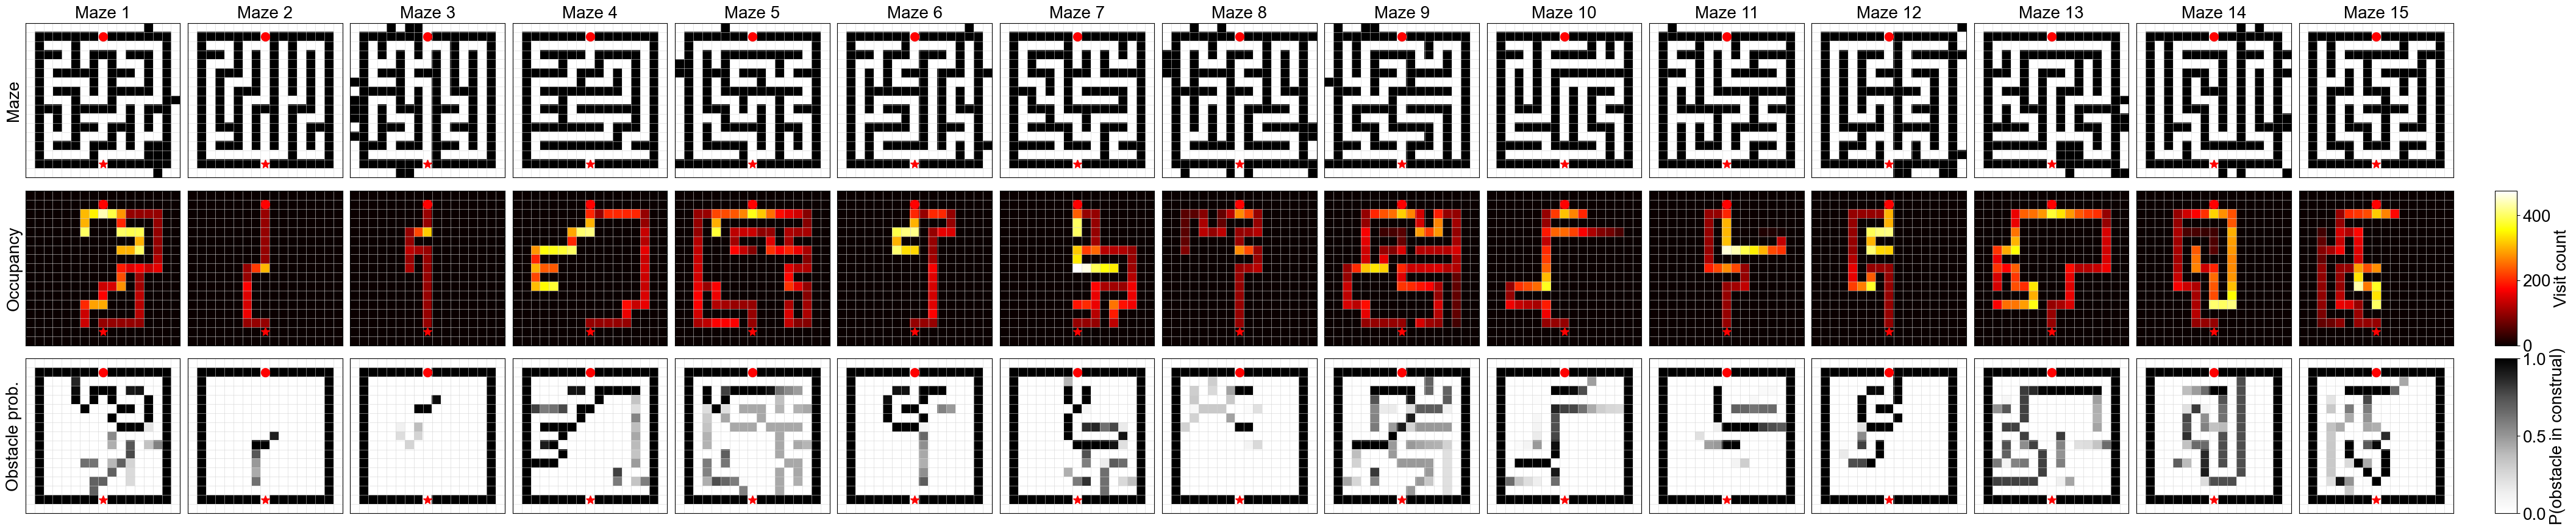

In [30]:
pars = jit.AStarPars(1.0, 1.0, 0.0, False) # Example parameters

fig, ax, results = run_jit_across_mazes_and_plot(
    test_mazes=test_mazes[0:15],
    start_goal_pos=start_goal_pos,
    pars=pars,
    n_sims=100,
    seed=0,
    xy_to_rc=True,
    binary_per_rollout=False,
    figsize_per_maze=(3,3),
    shared_colorbars=True,
    verbose=True,
)
fname = "exp1_occupancy_heatmaps_jit-shared"
# plt.savefig(os.path.join(figpath, fname+".png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(figpath, fname+".pdf"), bbox_inches="tight")
plt.show()